Mean error: 0.36104315519332886
Max error : 0.7203320264816284


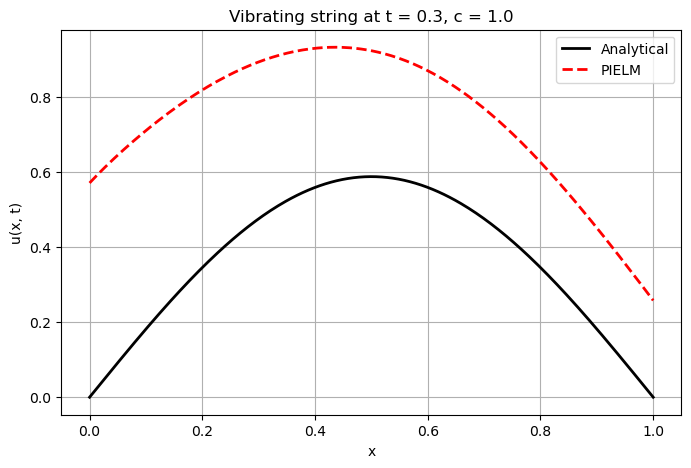

In [2]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Physical parameters
# -----------------------------
L = 1.0
T = 1.0
c_range = [0.9, 1.1]

# -----------------------------
# Exact solution
# -----------------------------
def exact_solution(x, t, c):
    return torch.cos(c * np.pi * t) * torch.sin(np.pi * x)

# -----------------------------
# ELM setup
# -----------------------------
torch.manual_seed(0)
hidden_size = 60

W = torch.randn(3, hidden_size)   # inputs: x, t, c
b = torch.randn(hidden_size)

def hidden_layer(x_tc):
    z = x_tc @ W + b
    return torch.exp(-z**2)

# -----------------------------
# Random PDE collocation points
# -----------------------------
n_pde = 3000

x_pde = torch.rand(n_pde, 1) * L
t_pde = torch.rand(n_pde, 1) * T
c_pde = torch.rand(n_pde, 1) * (c_range[1] - c_range[0]) + c_range[0]

X_pde = torch.cat([x_pde, t_pde, c_pde], dim=1).requires_grad_(True)

# -----------------------------
# Build PDE matrix
# u_tt - c^2 u_xx = 0
# -----------------------------
H = hidden_layer(X_pde)
A_cols = []

for j in range(hidden_size):
    hj = H[:, j:j+1]

    # u_t
    grad = autograd.grad(hj.sum(), X_pde, create_graph=True)[0]
    hj_t = grad[:, 1:2]

    # u_tt
    grad = autograd.grad(hj_t.sum(), X_pde, create_graph=True)[0]
    hj_tt = grad[:, 1:2]

    # u_x
    grad = autograd.grad(hj.sum(), X_pde, create_graph=True)[0]
    hj_x = grad[:, 0:1]

    # u_xx
    grad = autograd.grad(hj_x.sum(), X_pde, create_graph=True)[0]
    hj_xx = grad[:, 0:1]

    c_vals = X_pde[:, 2:3]
    A_cols.append(hj_tt - (c_vals**2) * hj_xx)

A = torch.hstack(A_cols)
A_aug = torch.hstack([A, torch.zeros(n_pde, 1)])
b_pde = torch.zeros(n_pde, 1)

# -----------------------------
# Boundary + Initial conditions
# -----------------------------
def build_constraint(X, order, var):
    H = hidden_layer(X)
    cols = []

    for j in range(hidden_size):
        hj = H[:, j:j+1]
        cur = hj
        for _ in range(order):
            grad = autograd.grad(cur.sum(), X, create_graph=True)[0]
            cur = grad[:, var:var+1]
        cols.append(cur)

    bias = torch.ones(X.shape[0], 1) if order == 0 else torch.zeros(X.shape[0], 1)
    return torch.hstack([torch.hstack(cols), bias])

n_bc = 400

# Boundary: x=0 and x=L
t_bc = torch.rand(n_bc, 1) * T
c_bc = torch.rand(n_bc, 1) * (c_range[1] - c_range[0]) + c_range[0]

X0 = torch.cat([torch.zeros(n_bc,1), t_bc, c_bc], dim=1).requires_grad_(True)
XL = torch.cat([L*torch.ones(n_bc,1), t_bc, c_bc], dim=1).requires_grad_(True)

# Initial: t=0
x_ic = torch.rand(n_bc, 1) * L
c_ic = torch.rand(n_bc, 1) * (c_range[1] - c_range[0]) + c_range[0]

Xic = torch.cat([x_ic, torch.zeros(n_bc,1), c_ic], dim=1).requires_grad_(True)

C = torch.vstack([
    build_constraint(X0, 0, 0),       # u(0,t)=0
    build_constraint(XL, 0, 0),       # u(L,t)=0
    build_constraint(Xic, 0, 0),      # u(x,0)=sin(pi x)
    build_constraint(Xic, 1, 1)       # u_t(x,0)=0
])

d = torch.vstack([
    torch.zeros(2*n_bc,1),
    torch.sin(np.pi * x_ic),
    torch.zeros(n_bc,1)
])

# -----------------------------
# Solve KKT system
# -----------------------------
A_T = A_aug.T
C_T = C.T

KKT = torch.zeros(hidden_size+1+C.shape[0], hidden_size+1+C.shape[0])
KKT[:hidden_size+1,:hidden_size+1] = A_T @ A_aug
KKT[:hidden_size+1,hidden_size+1:] = C_T
KKT[hidden_size+1:,:hidden_size+1] = C

rhs = torch.vstack([A_T @ b_pde, d])

reg = 1e-8 * torch.trace(A_T @ A_aug)/(hidden_size+1)
KKT[:hidden_size+1,:hidden_size+1] += reg * torch.eye(hidden_size+1)

sol = torch.linalg.solve(KKT, rhs)

beta = sol[:hidden_size]
beta0 = sol[hidden_size].item()

# -----------------------------
# Test / Validation
# -----------------------------
x_test = torch.rand(2000,1)*L
t_test = torch.rand(2000,1)*T
c_test = torch.rand(2000,1)*(c_range[1]-c_range[0])+c_range[0]

X_test = torch.cat([x_test,t_test,c_test],dim=1)
u_pred = hidden_layer(X_test) @ beta + beta0
u_exact = exact_solution(x_test,t_test,c_test)

error = torch.abs(u_pred - u_exact)
print("Mean error:", error.mean().item())
print("Max error :", error.max().item())
# -----------------------------
# Plot analytical vs PIELM curve
# -----------------------------

# Fixed slice
t0 = 0.3
c0 = 1.0

# Spatial grid
x_plot = torch.linspace(0, L, 300).reshape(-1, 1)
t_plot = t0 * torch.ones_like(x_plot)
c_plot = c0 * torch.ones_like(x_plot)

X_plot = torch.cat([x_plot, t_plot, c_plot], dim=1)

# PIELM prediction
u_pielm = hidden_layer(X_plot) @ beta + beta0

# Analytical solution
u_analytic = exact_solution(x_plot, t_plot, c_plot)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x_plot.numpy(), u_analytic.numpy(),
         'k-', linewidth=2, label='Analytical')
plt.plot(x_plot.numpy(), u_pielm.detach().numpy(),
         'r--', linewidth=2, label='PIELM')

plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.title(f"Vibrating string at t = {t0}, c = {c0}")
plt.legend()
plt.grid(True)
plt.show()



Mean error: 4.249112129211426
Max error : 5.500882148742676


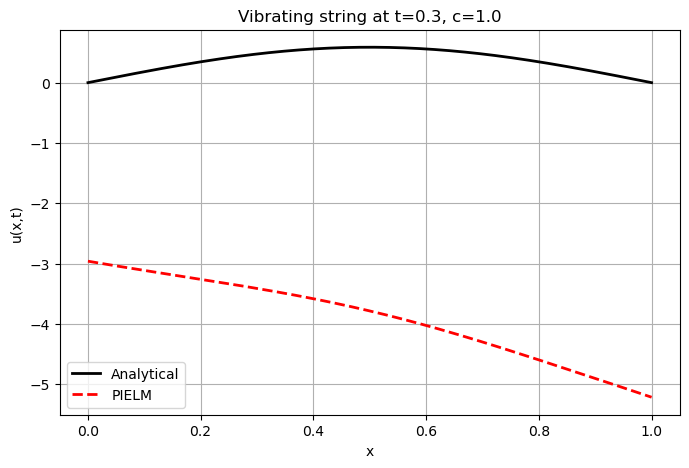

In [3]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

# ======================================
# Physical parameters
# ======================================
L = 1.0
T = 1.0
c_range = [0.9, 1.1]

# ======================================
# Exact solution
# ======================================
def exact_solution(x, t, c):
    return torch.cos(c * np.pi * t) * torch.sin(np.pi * x)

# ======================================
# ELM setup
# ======================================
torch.manual_seed(0)
hidden_size = 60

# Inputs: x, t, c
W = torch.randn(3, hidden_size)
b = torch.randn(hidden_size)

def hidden_layer(X):
    z = X @ W + b
    return torch.exp(-z**2)

# ======================================
# Random PDE collocation points
# ======================================
n_pde = 2000

x_pde = torch.rand(n_pde, 1) * L
t_pde = torch.rand(n_pde, 1) * T
c_pde = torch.rand(n_pde, 1) * (c_range[1] - c_range[0]) + c_range[0]

X_pde = torch.cat([x_pde, t_pde, c_pde], dim=1).requires_grad_(True)

# ======================================
# Build PDE matrix: u_tt - c^2 u_xx = 0
# ======================================
H = hidden_layer(X_pde)
A_cols = []

for j in range(hidden_size):
    hj = H[:, j:j+1]

    grad = autograd.grad(hj.sum(), X_pde, create_graph=True)[0]
    hj_x = grad[:, 0:1]
    hj_t = grad[:, 1:2]

    grad = autograd.grad(hj_x.sum(), X_pde, create_graph=True)[0]
    hj_xx = grad[:, 0:1]

    grad = autograd.grad(hj_t.sum(), X_pde, create_graph=True)[0]
    hj_tt = grad[:, 1:2]

    c_vals = X_pde[:, 2:3]
    A_cols.append(hj_tt - (c_vals**2) * hj_xx)

A = torch.hstack(A_cols)
b_pde = torch.zeros(n_pde, 1)

# ======================================
# Boundary & Initial Conditions
# ======================================
def build_constraint(X, order, var):
    H = hidden_layer(X)
    cols = []

    for j in range(hidden_size):
        cur = H[:, j:j+1]
        for _ in range(order):
            grad = autograd.grad(cur.sum(), X, create_graph=True)[0]
            cur = grad[:, var:var+1]
        cols.append(cur)

    return torch.hstack(cols)

n_bc = 1000

# Boundary: x = 0 and x = L
t_bc = torch.rand(n_bc, 1) * T
c_bc = torch.rand(n_bc, 1) * (c_range[1] - c_range[0]) + c_range[0]

X0 = torch.cat([torch.zeros(n_bc,1), t_bc, c_bc], dim=1).requires_grad_(True)
XL = torch.cat([L*torch.ones(n_bc,1), t_bc, c_bc], dim=1).requires_grad_(True)

# Initial conditions: t = 0
x_ic = torch.rand(n_bc, 1) * L
c_ic = torch.rand(n_bc, 1) * (c_range[1] - c_range[0]) + c_range[0]

Xic = torch.cat([x_ic, torch.zeros(n_bc,1), c_ic], dim=1).requires_grad_(True)

C = torch.vstack([
    build_constraint(X0, 0, 0),     # u(0,t) = 0
    build_constraint(XL, 0, 0),     # u(L,t) = 0
    build_constraint(Xic, 0, 0),    # u(x,0)
    build_constraint(Xic, 1, 1)     # u_t(x,0)
])

d = torch.vstack([
    torch.zeros(2*n_bc, 1),
    torch.sin(np.pi * x_ic),
    torch.zeros(n_bc, 1)
])

# ======================================
# Solve constrained least squares (KKT)
# ======================================
A_T = A.T
C_T = C.T

KKT = torch.zeros(hidden_size + C.shape[0], hidden_size + C.shape[0])

KKT[:hidden_size, :hidden_size] = A_T @ A
KKT[:hidden_size, hidden_size:] = C_T
KKT[hidden_size:, :hidden_size] = C

rhs = torch.vstack([A_T @ b_pde, d])

reg = 1e-8 * torch.trace(A_T @ A) / hidden_size
KKT[:hidden_size, :hidden_size] += reg * torch.eye(hidden_size)

sol = torch.linalg.solve(KKT, rhs)

beta = sol[:hidden_size]

# ======================================
# Validation
# ======================================
x_test = torch.rand(2000,1) * L
t_test = torch.rand(2000,1) * T
c_test = torch.rand(2000,1) * (c_range[1] - c_range[0]) + c_range[0]

X_test = torch.cat([x_test, t_test, c_test], dim=1)

u_pielm = hidden_layer(X_test) @ beta
u_exact = exact_solution(x_test, t_test, c_test)

error = torch.abs(u_pielm - u_exact)
print("Mean error:", error.mean().item())
print("Max error :", error.max().item())

# ======================================
# Plot: Analytical vs PIELM
# ======================================
t0 = 0.3
c0 = 1.0

x_plot = torch.linspace(0, L, 300).reshape(-1,1)
t_plot = t0 * torch.ones_like(x_plot)
c_plot = c0 * torch.ones_like(x_plot)

X_plot = torch.cat([x_plot, t_plot, c_plot], dim=1)

u_pielm_plot = hidden_layer(X_plot) @ beta
u_exact_plot = exact_solution(x_plot, t_plot, c_plot)

plt.figure(figsize=(8,5))
plt.plot(x_plot.numpy(), u_exact_plot.numpy(), 'k-', lw=2, label='Analytical')
plt.plot(x_plot.numpy(), u_pielm_plot.detach().numpy(), 'r--', lw=2, label='PIELM')
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title(f"Vibrating string at t={t0}, c={c0}")
plt.legend()
plt.grid(True)
plt.show()


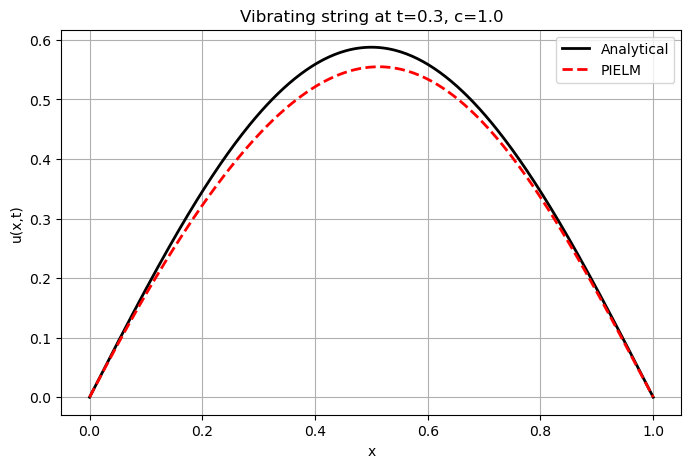

In [4]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

# ======================================
# Physical parameters
# ======================================
L = 1.0
T = 1.0
c_range = [0.9, 1.1]

# ======================================
# Exact solution (for validation)
# ======================================
def exact_solution(x, t, c):
    return torch.cos(c * np.pi * t) * torch.sin(np.pi * x)

# ======================================
# ELM setup
# ======================================
torch.manual_seed(0)
hidden_size = 60

# Inputs: x, t, c
W = torch.randn(3, hidden_size)
b = torch.randn(hidden_size)

def hidden_layer(X):
    z = X @ W + b
    return torch.exp(-z**2)

# ======================================
# Random PDE collocation points
# ======================================
n_pde = 3000

x_pde = torch.rand(n_pde, 1) * L
t_pde = torch.rand(n_pde, 1) * T
c_pde = torch.rand(n_pde, 1) * (c_range[1] - c_range[0]) + c_range[0]

X_pde = torch.cat([x_pde, t_pde, c_pde], dim=1).requires_grad_(True)

# ======================================
# Trial solution with embedded BCs
# u(x,t,c) = x(L-x) * NN(x,t,c)
# ======================================
H = hidden_layer(X_pde)
x = X_pde[:, 0:1]

U = x * (L - x) * H

# ======================================
# Build PDE matrix: u_tt - c^2 u_xx = 0
# ======================================
A_cols = []

for j in range(hidden_size):
    uj = U[:, j:j+1]

    # u_t
    grad = autograd.grad(uj.sum(), X_pde, create_graph=True)[0]
    uj_t = grad[:, 1:2]

    # u_tt
    grad = autograd.grad(uj_t.sum(), X_pde, create_graph=True)[0]
    uj_tt = grad[:, 1:2]

    # u_x
    grad = autograd.grad(uj.sum(), X_pde, create_graph=True)[0]
    uj_x = grad[:, 0:1]

    # u_xx
    grad = autograd.grad(uj_x.sum(), X_pde, create_graph=True)[0]
    uj_xx = grad[:, 0:1]

    c_vals = X_pde[:, 2:3]
    A_cols.append(uj_tt - (c_vals**2) * uj_xx)

A = torch.hstack(A_cols)
b_pde = torch.zeros(n_pde, 1)

# ======================================
# Initial conditions (ONLY)
# ======================================
n_ic = 1500

x_ic = torch.rand(n_ic, 1) * L
c_ic = torch.rand(n_ic, 1) * (c_range[1] - c_range[0]) + c_range[0]
t_ic = torch.zeros(n_ic, 1)

X_ic = torch.cat([x_ic, t_ic, c_ic], dim=1).requires_grad_(True)

H_ic = hidden_layer(X_ic)
x0 = X_ic[:, 0:1]
U_ic = x0 * (L - x0) * H_ic

# u(x,0)
C1 = U_ic
d1 = torch.sin(np.pi * x_ic)

# u_t(x,0)
C2_cols = []
for j in range(hidden_size):
    uj = U_ic[:, j:j+1]
    grad = autograd.grad(uj.sum(), X_ic, create_graph=True)[0]
    C2_cols.append(grad[:, 1:2])

C2 = torch.hstack(C2_cols)
d2 = torch.zeros(n_ic, 1)

# Combine constraints
C = torch.vstack([C1, C2])
d = torch.vstack([d1, d2])

# ======================================
# Solve constrained least squares (KKT)
# ======================================
A_T = A.T
C_T = C.T

KKT = torch.zeros(hidden_size + C.shape[0], hidden_size + C.shape[0])

KKT[:hidden_size, :hidden_size] = A_T @ A
KKT[:hidden_size, hidden_size:] = C_T
KKT[hidden_size:, :hidden_size] = C

rhs = torch.vstack([A_T @ b_pde, d])

reg = 1e-8 * torch.trace(A_T @ A) / hidden_size
KKT[:hidden_size, :hidden_size] += reg * torch.eye(hidden_size)

sol = torch.linalg.solve(KKT, rhs)
beta = sol[:hidden_size]

# ======================================
# Validation & Plot
# ======================================
t0 = 0.3
c0 = 1.0

x_plot = torch.linspace(0, L, 300).reshape(-1,1)
t_plot = t0 * torch.ones_like(x_plot)
c_plot = c0 * torch.ones_like(x_plot)

X_plot = torch.cat([x_plot, t_plot, c_plot], dim=1)

u_pielm = x_plot * (L - x_plot) * (hidden_layer(X_plot) @ beta)
u_exact = exact_solution(x_plot, t_plot, c_plot)

plt.figure(figsize=(8,5))
plt.plot(x_plot.numpy(), u_exact.numpy(), 'k-', lw=2, label='Analytical')
plt.plot(x_plot.numpy(), u_pielm.detach().numpy(), 'r--', lw=2, label='PIELM')
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title(f"Vibrating string at t={t0}, c={c0}")
plt.legend()
plt.grid(True)
plt.show()


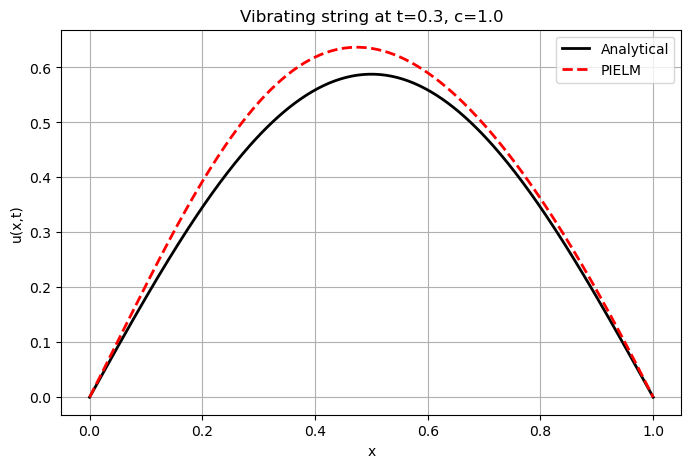

In [5]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Latin Hypercube Sampling (LHS)
# =========================================================
def latin_hypercube_sampling(n, d):
    """
    Generate n samples in d dimensions in [0,1]^d
    using Latin Hypercube Sampling
    """
    H = torch.zeros(n, d)
    for j in range(d):
        perm = torch.randperm(n)
        H[:, j] = (perm + torch.rand(n)) / n
    return H


# =========================================================
# Physical parameters
# =========================================================
L = 1.0
T = 1.0
c_range = [0.9, 1.1]


# =========================================================
# Exact solution (for validation)
# =========================================================
def exact_solution(x, t, c):
    return torch.cos(c * np.pi * t) * torch.sin(np.pi * x)


# =========================================================
# ELM setup (Gaussian activation)
# =========================================================
torch.manual_seed(0)
hidden_size = 60

# Inputs = (x, t, c)
W = torch.randn(3, hidden_size)
b = torch.randn(hidden_size)

def hidden_layer(X):
    z = X @ W + b
    return torch.exp(-z**2)


# =========================================================
# PDE collocation points (LHS)
# =========================================================
n_pde = 3000
lhs_pde = latin_hypercube_sampling(n_pde, 3)

x_pde = lhs_pde[:, 0:1] * L
t_pde = lhs_pde[:, 1:2] * T
c_pde = lhs_pde[:, 2:3] * (c_range[1] - c_range[0]) + c_range[0]

X_pde = torch.cat([x_pde, t_pde, c_pde], dim=1).requires_grad_(True)


# =========================================================
# Trial function with embedded BCs
# u(x,t,c) = x(L-x) * NN(x,t,c)
# =========================================================
H_pde = hidden_layer(X_pde)
x = X_pde[:, 0:1]
U = x * (L - x) * H_pde


# =========================================================
# Build PDE operator: u_tt - c^2 u_xx = 0
# =========================================================
A_cols = []

for j in range(hidden_size):
    uj = U[:, j:j+1]

    grad = autograd.grad(uj.sum(), X_pde, create_graph=True)[0]
    uj_x = grad[:, 0:1]
    uj_t = grad[:, 1:2]

    grad = autograd.grad(uj_x.sum(), X_pde, create_graph=True)[0]
    uj_xx = grad[:, 0:1]

    grad = autograd.grad(uj_t.sum(), X_pde, create_graph=True)[0]
    uj_tt = grad[:, 1:2]

    c_vals = X_pde[:, 2:3]
    A_cols.append(uj_tt - (c_vals**2) * uj_xx)

A = torch.hstack(A_cols)
b_pde = torch.zeros(n_pde, 1)


# =========================================================
# Initial condition points (LHS)
# =========================================================
n_ic = 1500
lhs_ic = latin_hypercube_sampling(n_ic, 2)

x_ic = lhs_ic[:, 0:1] * L
c_ic = lhs_ic[:, 1:2] * (c_range[1] - c_range[0]) + c_range[0]
t_ic = torch.zeros(n_ic, 1)

X_ic = torch.cat([x_ic, t_ic, c_ic], dim=1).requires_grad_(True)

H_ic = hidden_layer(X_ic)
x0 = X_ic[:, 0:1]
U_ic = x0 * (L - x0) * H_ic


# =========================================================
# Initial conditions
# u(x,0) = sin(pi x)
# u_t(x,0) = 0
# =========================================================
C1 = U_ic
d1 = torch.sin(np.pi * x_ic)

C2_cols = []
for j in range(hidden_size):
    uj = U_ic[:, j:j+1]
    grad = autograd.grad(uj.sum(), X_ic, create_graph=True)[0]
    C2_cols.append(grad[:, 1:2])

C2 = torch.hstack(C2_cols)
d2 = torch.zeros(n_ic, 1)

C = torch.vstack([C1, C2])
d = torch.vstack([d1, d2])


# =========================================================
# KKT system (constrained least squares)
# =========================================================
A_T = A.T
C_T = C.T

KKT = torch.zeros(hidden_size + C.shape[0],
                  hidden_size + C.shape[0])

KKT[:hidden_size, :hidden_size] = A_T @ A
KKT[:hidden_size, hidden_size:] = C_T
KKT[hidden_size:, :hidden_size] = C

rhs = torch.vstack([A_T @ b_pde, d])

reg = 1e-8 * torch.trace(A_T @ A) / hidden_size
KKT[:hidden_size, :hidden_size] += reg * torch.eye(hidden_size)

sol = torch.linalg.solve(KKT, rhs)
beta = sol[:hidden_size]


# =========================================================
# Validation plot: Analytical vs PIELM
# =========================================================
t0 = 0.3
c0 = 1.0

x_plot = torch.linspace(0, L, 300).reshape(-1,1)
t_plot = t0 * torch.ones_like(x_plot)
c_plot = c0 * torch.ones_like(x_plot)

X_plot = torch.cat([x_plot, t_plot, c_plot], dim=1)

u_pielm = x_plot * (L - x_plot) * (hidden_layer(X_plot) @ beta)
u_exact = exact_solution(x_plot, t_plot, c_plot)

plt.figure(figsize=(8,5))
plt.plot(x_plot.numpy(), u_exact.numpy(), 'k-', lw=2, label='Analytical')
plt.plot(x_plot.numpy(), u_pielm.detach().numpy(), 'r--', lw=2, label='PIELM')
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title(f"Vibrating string at t={t0}, c={c0}")
plt.legend()
plt.grid(True)
plt.show()


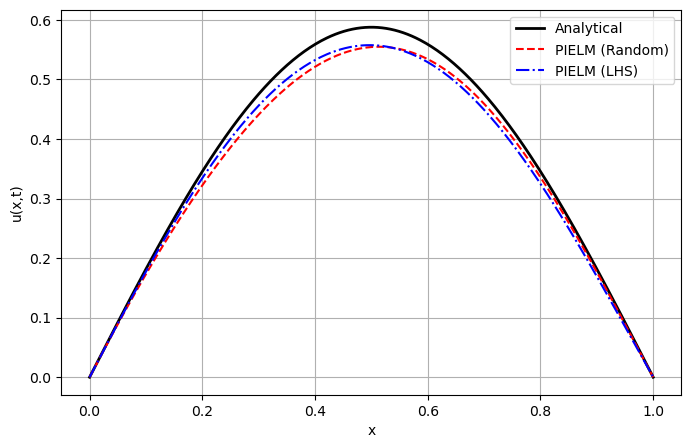

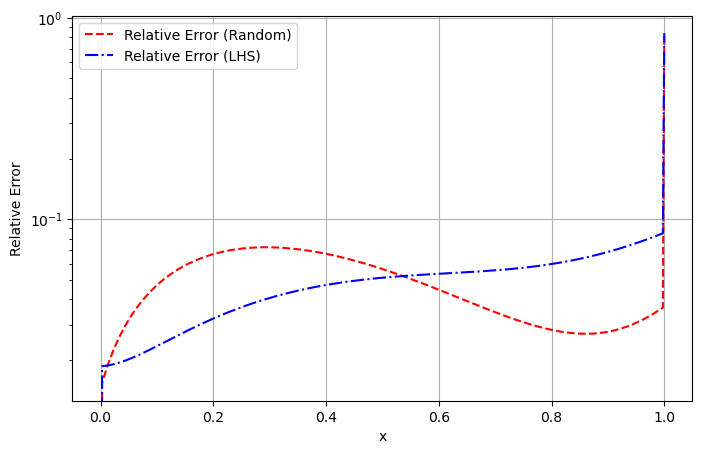

In [11]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Latin Hypercube Sampling
# =========================================================
def latin_hypercube_sampling(n, d):
    H = torch.zeros(n, d)
    for j in range(d):
        perm = torch.randperm(n)
        H[:, j] = (perm + torch.rand(n)) / n
    return H

# =========================================================
# Physical parameters
# =========================================================
L = 1.0
T = 1.0
c_range = [0.9, 1.1]

def exact_solution(x, t, c):
    return torch.cos(c * np.pi * t) * torch.sin(np.pi * x)

# =========================================================
# ELM setup (Gaussian activation)
# =========================================================
torch.manual_seed(0)
hidden_size = 60

W = torch.randn(3, hidden_size)
b = torch.randn(hidden_size)

def hidden_layer(X):
    return torch.exp(-(X @ W + b) ** 2)

# =========================================================
# PIELM SOLVER
# =========================================================
def solve_pielm(sampling="random"):
    n_pde = 3000
    n_ic = 1500

    # ---------------- PDE points ----------------
    if sampling == "random":
        x_pde = torch.rand(n_pde, 1) * L
        t_pde = torch.rand(n_pde, 1) * T
        c_pde = torch.rand(n_pde, 1) * (c_range[1] - c_range[0]) + c_range[0]
    else:
        lhs = latin_hypercube_sampling(n_pde, 3)
        x_pde = lhs[:, 0:1] * L
        t_pde = lhs[:, 1:2] * T
        c_pde = lhs[:, 2:3] * (c_range[1] - c_range[0]) + c_range[0]

    X_pde = torch.cat([x_pde, t_pde, c_pde], dim=1).requires_grad_(True)

    H = hidden_layer(X_pde)
    x = X_pde[:, 0:1]
    U = x * (L - x) * H

    # ---------------- PDE operator ----------------
    A_cols = []
    for j in range(hidden_size):
        uj = U[:, j:j+1]

        grad = autograd.grad(uj.sum(), X_pde, create_graph=True)[0]
        uj_x, uj_t = grad[:, 0:1], grad[:, 1:2]

        grad = autograd.grad(uj_x.sum(), X_pde, create_graph=True)[0]
        uj_xx = grad[:, 0:1]

        grad = autograd.grad(uj_t.sum(), X_pde, create_graph=True)[0]
        uj_tt = grad[:, 1:2]

        c_vals = X_pde[:, 2:3]
        A_cols.append(uj_tt - c_vals**2 * uj_xx)

    A = torch.hstack(A_cols)
    b_pde = torch.zeros(n_pde, 1)

    # ---------------- Initial conditions ----------------
    if sampling == "random":
        x_ic = torch.rand(n_ic, 1) * L
        c_ic = torch.rand(n_ic, 1) * (c_range[1] - c_range[0]) + c_range[0]
    else:
        lhs = latin_hypercube_sampling(n_ic, 2)
        x_ic = lhs[:, 0:1] * L
        c_ic = lhs[:, 1:2] * (c_range[1] - c_range[0]) + c_range[0]

    t_ic = torch.zeros(n_ic, 1)
    X_ic = torch.cat([x_ic, t_ic, c_ic], dim=1).requires_grad_(True)

    H_ic = hidden_layer(X_ic)
    x0 = X_ic[:, 0:1]
    U_ic = x0 * (L - x0) * H_ic

    C1 = U_ic
    d1 = torch.sin(np.pi * x_ic)

    C2_cols = []
    for j in range(hidden_size):
        uj = U_ic[:, j:j+1]
        grad = autograd.grad(uj.sum(), X_ic, create_graph=True)[0]
        C2_cols.append(grad[:, 1:2])

    C2 = torch.hstack(C2_cols)
    d2 = torch.zeros(n_ic, 1)

    C = torch.vstack([C1, C2])
    d = torch.vstack([d1, d2])

    # ---------------- KKT system ----------------
    A_T, C_T = A.T, C.T
    KKT = torch.zeros(hidden_size + C.shape[0],
                      hidden_size + C.shape[0])

    KKT[:hidden_size, :hidden_size] = A_T @ A
    KKT[:hidden_size, hidden_size:] = C_T
    KKT[hidden_size:, :hidden_size] = C

    rhs = torch.vstack([A_T @ b_pde, d])
    reg = 1e-8 * torch.trace(A_T @ A) / hidden_size
    KKT[:hidden_size, :hidden_size] += reg * torch.eye(hidden_size)

    sol = torch.linalg.solve(KKT, rhs)
    return sol[:hidden_size]

# =========================================================
# Solve both cases
# =========================================================
beta_rand = solve_pielm("random")
beta_lhs  = solve_pielm("lhs")

# =========================================================
# Evaluation slice
# =========================================================
t0, c0 = 0.3, 1.0
x_plot = torch.linspace(0, L, 400).reshape(-1, 1)
t_plot = t0 * torch.ones_like(x_plot)
c_plot = c0 * torch.ones_like(x_plot)

X_plot = torch.cat([x_plot, t_plot, c_plot], dim=1)

u_exact = exact_solution(x_plot, t_plot, c_plot)
u_rand  = x_plot * (L - x_plot) * (hidden_layer(X_plot) @ beta_rand)
u_lhs   = x_plot * (L - x_plot) * (hidden_layer(X_plot) @ beta_lhs)

# =========================================================
# Relative error
# =========================================================
eps = 1e-8
rel_err_rand = torch.abs(u_rand - u_exact) / (torch.abs(u_exact) + eps)
rel_err_lhs  = torch.abs(u_lhs  - u_exact) / (torch.abs(u_exact) + eps)

# =========================================================
# Plot: solution comparison
# =========================================================
plt.figure(figsize=(8,5))
plt.plot(x_plot.detach().numpy(),
         u_exact.detach().numpy(),
         'k', lw=2, label='Analytical')

plt.plot(x_plot.detach().numpy(),
         u_rand.detach().numpy(),
         'r--', label='PIELM (Random)')

plt.plot(x_plot.detach().numpy(),
         u_lhs.detach().numpy(),
         'b-.', label='PIELM (LHS)')

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# Plot: relative error comparison
# =========================================================
plt.figure(figsize=(8,5))
plt.semilogy(x_plot.detach().numpy(),
             rel_err_rand.detach().numpy(),
             'r--', label='Relative Error (Random)')

plt.semilogy(x_plot.detach().numpy(),
             rel_err_lhs.detach().numpy(),
             'b-.', label='Relative Error (LHS)')

plt.xlabel("x")
plt.ylabel("Relative Error")
plt.legend()
plt.grid(True)
plt.show()


Mean Relative Error (Random) = 4.9239 %
Max  Relative Error (Random) = 83.7096 %
Mean Relative Error (LHS)    = 5.0194 %
Max  Relative Error (LHS)    = 83.7096 %


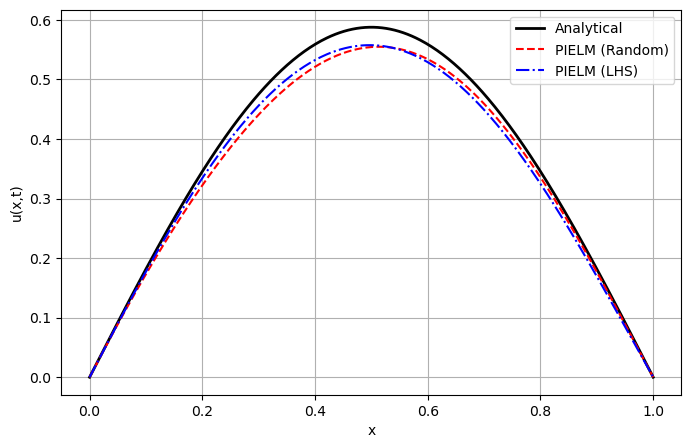

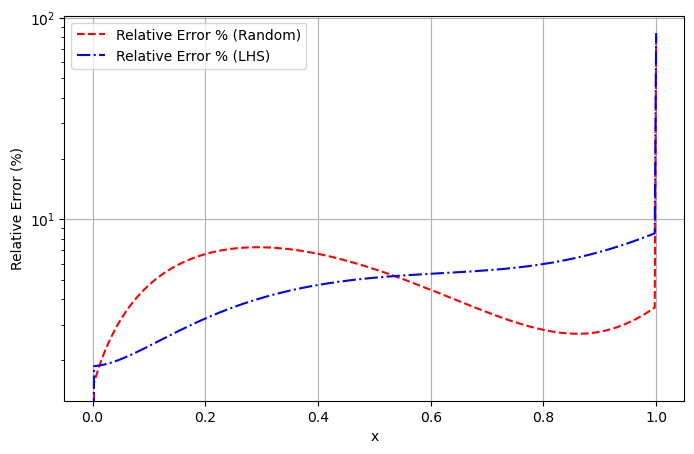

In [8]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Latin Hypercube Sampling
# =========================================================
def latin_hypercube_sampling(n, d):
    H = torch.zeros(n, d)
    for j in range(d):
        perm = torch.randperm(n)
        H[:, j] = (perm + torch.rand(n)) / n
    return H

# =========================================================
# Physical parameters
# =========================================================
L = 1.0
T = 1.0
c_range = [0.9, 1.1]

def exact_solution(x, t, c):
    return torch.cos(c * np.pi * t) * torch.sin(np.pi * x)

# =========================================================
# ELM setup (Gaussian activation)
# =========================================================
torch.manual_seed(0)
hidden_size = 60

W = torch.randn(3, hidden_size)
b = torch.randn(hidden_size)

def hidden_layer(X):
    return torch.exp(-(X @ W + b) ** 2)

# =========================================================
# PIELM solver
# =========================================================
def solve_pielm(sampling="random"):
    n_pde = 3000
    n_ic = 1500

    # ---------- PDE points ----------
    if sampling == "random":
        x_pde = torch.rand(n_pde,1) * L
        t_pde = torch.rand(n_pde,1) * T
        c_pde = torch.rand(n_pde,1) * (c_range[1]-c_range[0]) + c_range[0]
    else:
        lhs = latin_hypercube_sampling(n_pde,3)
        x_pde = lhs[:,0:1] * L
        t_pde = lhs[:,1:2] * T
        c_pde = lhs[:,2:3] * (c_range[1]-c_range[0]) + c_range[0]

    X_pde = torch.cat([x_pde,t_pde,c_pde],dim=1).requires_grad_(True)

    H = hidden_layer(X_pde)
    x = X_pde[:,0:1]
    U = x * (L-x) * H

    # ---------- PDE operator ----------
    A_cols = []
    for j in range(hidden_size):
        uj = U[:,j:j+1]

        grad = autograd.grad(uj.sum(), X_pde, create_graph=True)[0]
        uj_x, uj_t = grad[:,0:1], grad[:,1:2]

        grad = autograd.grad(uj_x.sum(), X_pde, create_graph=True)[0]
        uj_xx = grad[:,0:1]

        grad = autograd.grad(uj_t.sum(), X_pde, create_graph=True)[0]
        uj_tt = grad[:,1:2]

        c_vals = X_pde[:,2:3]
        A_cols.append(uj_tt - c_vals**2 * uj_xx)

    A = torch.hstack(A_cols)
    b_pde = torch.zeros(n_pde,1)

    # ---------- Initial conditions ----------
    if sampling == "random":
        x_ic = torch.rand(n_ic,1) * L
        c_ic = torch.rand(n_ic,1) * (c_range[1]-c_range[0]) + c_range[0]
    else:
        lhs = latin_hypercube_sampling(n_ic,2)
        x_ic = lhs[:,0:1] * L
        c_ic = lhs[:,1:2] * (c_range[1]-c_range[0]) + c_range[0]

    t_ic = torch.zeros(n_ic,1)
    X_ic = torch.cat([x_ic,t_ic,c_ic],dim=1).requires_grad_(True)

    H_ic = hidden_layer(X_ic)
    x0 = X_ic[:,0:1]
    U_ic = x0 * (L-x0) * H_ic

    C1 = U_ic
    d1 = torch.sin(np.pi * x_ic)

    C2_cols = []
    for j in range(hidden_size):
        uj = U_ic[:,j:j+1]
        grad = autograd.grad(uj.sum(), X_ic, create_graph=True)[0]
        C2_cols.append(grad[:,1:2])

    C2 = torch.hstack(C2_cols)
    d2 = torch.zeros(n_ic,1)

    C = torch.vstack([C1,C2])
    d = torch.vstack([d1,d2])

    # ---------- KKT system ----------
    A_T, C_T = A.T, C.T
    KKT = torch.zeros(hidden_size + C.shape[0],
                      hidden_size + C.shape[0])

    KKT[:hidden_size,:hidden_size] = A_T @ A
    KKT[:hidden_size,hidden_size:] = C_T
    KKT[hidden_size:,:hidden_size] = C

    rhs = torch.vstack([A_T @ b_pde, d])
    reg = 1e-8 * torch.trace(A_T @ A) / hidden_size
    KKT[:hidden_size,:hidden_size] += reg * torch.eye(hidden_size)

    sol = torch.linalg.solve(KKT,rhs)
    return sol[:hidden_size]

# =========================================================
# Solve both cases
# =========================================================
beta_rand = solve_pielm("random")
beta_lhs  = solve_pielm("lhs")

# =========================================================
# Evaluation slice
# =========================================================
t0, c0 = 0.3, 1.0
x_plot = torch.linspace(0,L,400).reshape(-1,1)
t_plot = t0 * torch.ones_like(x_plot)
c_plot = c0 * torch.ones_like(x_plot)

X_plot = torch.cat([x_plot,t_plot,c_plot],dim=1)

u_exact = exact_solution(x_plot,t_plot,c_plot)
u_rand  = x_plot*(L-x_plot)*(hidden_layer(X_plot) @ beta_rand)
u_lhs   = x_plot*(L-x_plot)*(hidden_layer(X_plot) @ beta_lhs)

# =========================================================
# Relative error (%) computation
# =========================================================
eps = 1e-8
rel_err_rand_pct = 100 * torch.abs(u_rand - u_exact) / (torch.abs(u_exact) + eps)
rel_err_lhs_pct  = 100 * torch.abs(u_lhs  - u_exact) / (torch.abs(u_exact) + eps)

print(f"Mean Relative Error (Random) = {rel_err_rand_pct.mean().item():.4f} %")
print(f"Max  Relative Error (Random) = {rel_err_rand_pct.max().item():.4f} %")
print(f"Mean Relative Error (LHS)    = {rel_err_lhs_pct.mean().item():.4f} %")
print(f"Max  Relative Error (LHS)    = {rel_err_lhs_pct.max().item():.4f} %")

# =========================================================
# Plot: solution comparison
# =========================================================
plt.figure(figsize=(8,5))
plt.plot(x_plot.detach().numpy(),
         u_exact.detach().numpy(),
         'k', lw=2, label='Analytical')

plt.plot(x_plot.detach().numpy(),
         u_rand.detach().numpy(),
         'r--', label='PIELM (Random)')

plt.plot(x_plot.detach().numpy(),
         u_lhs.detach().numpy(),
         'b-.', label='PIELM (LHS)')

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# Plot: relative error (%) comparison
# =========================================================
plt.figure(figsize=(8,5))
plt.semilogy(x_plot.detach().numpy(),
             rel_err_rand_pct.detach().numpy(),
             'r--', label='Relative Error % (Random)')

plt.semilogy(x_plot.detach().numpy(),
             rel_err_lhs_pct.detach().numpy(),
             'b-.', label='Relative Error % (LHS)')

plt.xlabel("x")
plt.ylabel("Relative Error (%)")
plt.legend()
plt.grid(True)
plt.show()


L2 Error (Random)      = 5.5619 %
L2 Error (LHS)         = 4.9957 %
Max Absolute Error (Random) = 3.7743e-02
Max Absolute Error (LHS)    = 3.0546e-02
Mean Absolute Error (Random)= 1.9372e-02
Mean Absolute Error (LHS)   = 1.8215e-02


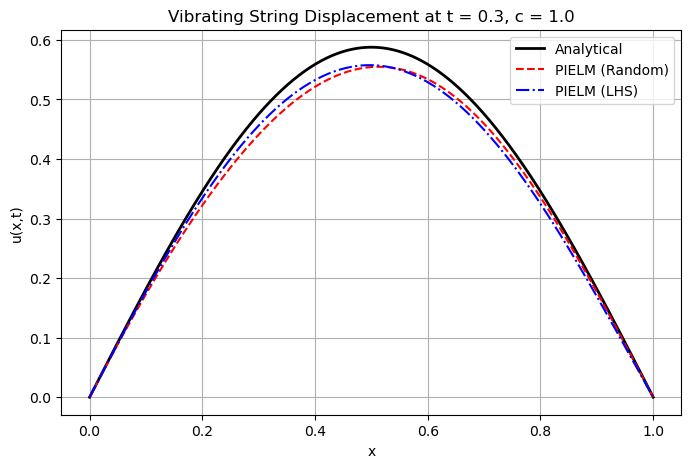

In [23]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Latin Hypercube Sampling
# =========================================================
def latin_hypercube_sampling(n, d):
    H = torch.zeros(n, d)
    for j in range(d):
        perm = torch.randperm(n)
        H[:, j] = (perm + torch.rand(n)) / n
    return H

# =========================================================
# Physical parameters
# =========================================================
L = 1.0
T = 1.0
c_range = [0.9, 1.1]

def exact_solution(x, t, c):
    return torch.cos(c * np.pi * t) * torch.sin(np.pi * x)

# =========================================================
# ELM setup (Gaussian activation)
# =========================================================
torch.manual_seed(0)
hidden_size = 60

W = torch.randn(3, hidden_size)
b = torch.randn(hidden_size)

def hidden_layer(X):
    return torch.exp(-(X @ W + b) ** 2)

# =========================================================
# PIELM solver
# =========================================================
def solve_pielm(sampling="random"):
    n_pde = 3000
    n_ic = 1500

    # ---------- PDE points ----------
    if sampling == "random":
        x_pde = torch.rand(n_pde,1)*L
        t_pde = torch.rand(n_pde,1)*T
        c_pde = torch.rand(n_pde,1)*(c_range[1]-c_range[0]) + c_range[0]
    else:
        lhs = latin_hypercube_sampling(n_pde,3)
        x_pde = lhs[:,0:1]*L
        t_pde = lhs[:,1:2]*T
        c_pde = lhs[:,2:3]*(c_range[1]-c_range[0]) + c_range[0]

    X_pde = torch.cat([x_pde,t_pde,c_pde],dim=1).requires_grad_(True)
    H = hidden_layer(X_pde)
    x = X_pde[:,0:1]
    U = x*(L-x)*H

    # ---------- PDE operator ----------
    A_cols = []
    for j in range(hidden_size):
        uj = U[:,j:j+1]

        grad = autograd.grad(uj.sum(), X_pde, create_graph=True)[0]
        uj_x, uj_t = grad[:,0:1], grad[:,1:2]

        grad = autograd.grad(uj_x.sum(), X_pde, create_graph=True)[0]
        uj_xx = grad[:,0:1]

        grad = autograd.grad(uj_t.sum(), X_pde, create_graph=True)[0]
        uj_tt = grad[:,1:2]

        c_vals = X_pde[:,2:3]
        A_cols.append(uj_tt - c_vals**2 * uj_xx)

    A = torch.hstack(A_cols)
    b_pde = torch.zeros(n_pde,1)

    # ---------- Initial conditions ----------
    if sampling == "random":
        x_ic = torch.rand(n_ic,1)*L
        c_ic = torch.rand(n_ic,1)*(c_range[1]-c_range[0]) + c_range[0]
    else:
        lhs = latin_hypercube_sampling(n_ic,2)
        x_ic = lhs[:,0:1]*L
        c_ic = lhs[:,1:2]*(c_range[1]-c_range[0]) + c_range[0]

    t_ic = torch.zeros(n_ic,1)
    X_ic = torch.cat([x_ic,t_ic,c_ic],dim=1).requires_grad_(True)

    H_ic = hidden_layer(X_ic)
    x0 = X_ic[:,0:1]
    U_ic = x0*(L-x0)*H_ic

    C1 = U_ic
    d1 = torch.sin(np.pi*x_ic)

    C2_cols = []
    for j in range(hidden_size):
        uj = U_ic[:,j:j+1]
        grad = autograd.grad(uj.sum(), X_ic, create_graph=True)[0]
        C2_cols.append(grad[:,1:2])

    C2 = torch.hstack(C2_cols)
    d2 = torch.zeros(n_ic,1)

    C = torch.vstack([C1,C2])
    d = torch.vstack([d1,d2])

    # ---------- KKT system ----------
    A_T, C_T = A.T, C.T
    KKT = torch.zeros(hidden_size + C.shape[0],
                      hidden_size + C.shape[0])

    KKT[:hidden_size,:hidden_size] = A_T @ A
    KKT[:hidden_size,hidden_size:] = C_T
    KKT[hidden_size:,:hidden_size] = C

    rhs = torch.vstack([A_T@b_pde, d])
    reg = 1e-8 * torch.trace(A_T@A) / hidden_size
    KKT[:hidden_size,:hidden_size] += reg * torch.eye(hidden_size)

    sol = torch.linalg.solve(KKT, rhs)
    return sol[:hidden_size]

# =========================================================
# Solve both cases
# =========================================================
beta_rand = solve_pielm("random")
beta_lhs  = solve_pielm("lhs")

# =========================================================
# Evaluation slice
# =========================================================
t0, c0 = 0.3, 1.0
x_plot = torch.linspace(0,L,400).reshape(-1,1)
t_plot = t0*torch.ones_like(x_plot)
c_plot = c0*torch.ones_like(x_plot)

X_plot = torch.cat([x_plot,t_plot,c_plot],dim=1)

u_exact = exact_solution(x_plot,t_plot,c_plot)
u_rand  = x_plot*(L-x_plot)*(hidden_layer(X_plot)@beta_rand)
u_lhs   = x_plot*(L-x_plot)*(hidden_layer(X_plot)@beta_lhs)

# =========================================================
# ERROR METRICS (NO relative error)
# =========================================================
L2_rand = 100 * torch.norm(u_rand-u_exact) / torch.norm(u_exact)
L2_lhs  = 100 * torch.norm(u_lhs -u_exact) / torch.norm(u_exact)

max_abs_rand = torch.max(torch.abs(u_rand-u_exact))
max_abs_lhs  = torch.max(torch.abs(u_lhs -u_exact))

mean_abs_rand = torch.mean(torch.abs(u_rand-u_exact))
mean_abs_lhs  = torch.mean(torch.abs(u_lhs -u_exact))

print(f"L2 Error (Random)      = {L2_rand.item():.4f} %")
print(f"L2 Error (LHS)         = {L2_lhs.item():.4f} %")
print(f"Max Absolute Error (Random) = {max_abs_rand.item():.4e}")
print(f"Max Absolute Error (LHS)    = {max_abs_lhs.item():.4e}")
print(f"Mean Absolute Error (Random)= {mean_abs_rand.item():.4e}")
print(f"Mean Absolute Error (LHS)   = {mean_abs_lhs.item():.4e}")

# =========================================================
# Plot
# =========================================================
plt.figure(figsize=(8,5))
plt.plot(x_plot.detach().numpy(),
         u_exact.detach().numpy(),
         'k', lw=2, label='Analytical')
plt.plot(x_plot.detach().numpy(),
         u_rand.detach().numpy(),
         'r--', label='PIELM (Random)')
plt.plot(x_plot.detach().numpy(),
         u_lhs.detach().numpy(),
         'b-.', label='PIELM (LHS)')
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Vibrating String Displacement at t = 0.3, c = 1.0")

plt.legend()
plt.grid(True)
plt.show()


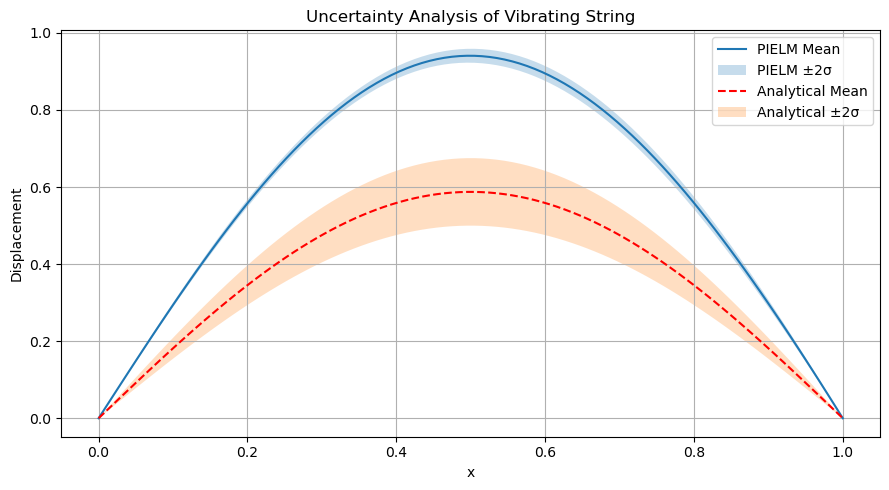

Sensitivity analysis at x = L/2
∂u/∂c = -1.5872e-01
Normalized sensitivity wrt c = -0.169


In [2]:
# =============================================================================
# IMPORTS
# =============================================================================
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)
torch.manual_seed(0)
np.random.seed(0)

# =============================================================================
# LATIN HYPERCUBE SAMPLING (MANUAL)
# =============================================================================
def latin_hypercube_sampling(n_samples, n_dim):
    rng = np.random.default_rng()
    H = np.zeros((n_samples, n_dim), dtype=np.float32)
    for j in range(n_dim):
        perm = rng.permutation(n_samples)
        H[:, j] = (perm + rng.random(n_samples)) / n_samples
    return H

# =============================================================================
# PROBLEM PARAMETERS
# =============================================================================
L = 1.0
T = 1.0
c_range = [0.9, 1.1]

# =============================================================================
# ANALYTICAL SOLUTION
# =============================================================================
def analytical_solution(x, t, c):
    return torch.cos(c * np.pi * t) * torch.sin(np.pi * x)

# =============================================================================
# PIELM TRAINING
# =============================================================================
def train_pielm(hidden_neurons=80, n_pde=4000, n_ic=2000):

    W = torch.randn(3, hidden_neurons) * 0.5
    b = torch.randn(hidden_neurons) * 0.5

    def gaussian(z):
        return torch.exp(-z**2)

    # ---------------- PDE points (LHS) ----------------
    s = latin_hypercube_sampling(n_pde, 3)

    x = torch.from_numpy(s[:,0:1]) * L
    t = torch.from_numpy(s[:,1:2]) * T
    c = torch.from_numpy(s[:,2:3]) * (c_range[1]-c_range[0]) + c_range[0]

    X = torch.cat([x,t,c], dim=1).float()
    X.requires_grad_(True)

    H = gaussian(X @ W + b)
    U = x*(L-x)*H

    # PDE operator
    A_cols = []
    for j in range(hidden_neurons):

        uj = U[:,j:j+1]

        grad = autograd.grad(uj.sum(), X, create_graph=True)[0]
        uj_x = grad[:,0:1]
        uj_t = grad[:,1:2]

        uj_xx = autograd.grad(uj_x.sum(), X, create_graph=True)[0][:,0:1]
        uj_tt = autograd.grad(uj_t.sum(), X, create_graph=True)[0][:,1:2]

        c_vals = X[:,2:3]
        A_cols.append(uj_tt - c_vals**2 * uj_xx)

    A = torch.hstack(A_cols)
    b_vec = torch.zeros(n_pde,1)

    # ---------------- Initial conditions ----------------
    s_ic = latin_hypercube_sampling(n_ic,2)

    x_ic = torch.from_numpy(s_ic[:,0:1]) * L
    c_ic = torch.from_numpy(s_ic[:,1:2]) * (c_range[1]-c_range[0]) + c_range[0]
    t_ic = torch.zeros(n_ic,1)

    X_ic = torch.cat([x_ic,t_ic,c_ic], dim=1).float()
    X_ic.requires_grad_(True)

    H_ic = gaussian(X_ic @ W + b)
    U_ic = x_ic*(L-x_ic)*H_ic

    C1 = U_ic
    d1 = torch.sin(np.pi*x_ic)

    C2_cols = []
    for j in range(hidden_neurons):
        uj = U_ic[:,j:j+1]
        grad = autograd.grad(uj.sum(), X_ic, create_graph=True)[0]
        C2_cols.append(grad[:,1:2])

    C2 = torch.hstack(C2_cols)
    d2 = torch.zeros(n_ic,1)

    C = torch.vstack([C1,C2])
    d = torch.vstack([d1,d2])

    # ---------------- KKT system ----------------
    n = hidden_neurons
    KKT = torch.zeros(n + C.shape[0], n + C.shape[0])

    KKT[:n,:n] = A.T @ A + 1e-6*torch.eye(n)
    KKT[:n,n:] = C.T
    KKT[n:,:n] = C

    rhs = torch.vstack([A.T@b_vec, d])

    beta = torch.linalg.solve(KKT, rhs)[:n]

    def predict(X_input):
        H = gaussian(X_input @ W + b)
        x_val = X_input[:,0:1]
        return x_val*(L-x_val)*(H @ beta)

    return predict

# =============================================================================
# TRAIN MODEL
# =============================================================================
predict = train_pielm()

# =============================================================================
# UNCERTAINTY ANALYSIS (MONTE CARLO)
# =============================================================================
n_mc = 5000
x_uq = torch.linspace(0, L, 100).reshape(-1, 1)
t_fixed = 0.3

c_mc = c_range[0] + torch.rand(n_mc, 1) * (c_range[1]-c_range[0])

u_samples = []

for x_val in x_uq:
    x_rep = x_val.repeat(n_mc, 1)
    t_rep = torch.ones_like(x_rep) * t_fixed

    X_mc = torch.cat([x_rep, t_rep, c_mc], dim=1)
    u_samples.append(predict(X_mc))

u_samples = torch.stack(u_samples)

u_mean = u_samples.mean(dim=1).squeeze()
u_std  = u_samples.std(dim=1).squeeze()

# Analytical statistics
shape = torch.sin(np.pi * x_uq.squeeze())
cos_term = torch.cos(c_mc.squeeze() * np.pi * t_fixed)

u_mean_exact = shape * cos_term.mean()
u_std_exact  = shape.abs() * cos_term.std()

# Detach for plotting
x_np = x_uq.detach().numpy()
u_mean_np = u_mean.detach().numpy()
u_std_np = u_std.detach().numpy()
u_mean_ex_np = u_mean_exact.detach().numpy()
u_std_ex_np = u_std_exact.detach().numpy()

# =============================================================================
# UNCERTAINTY PLOT
# =============================================================================
plt.figure(figsize=(9,5))

plt.plot(x_np, u_mean_np, label="PIELM Mean")
plt.fill_between(x_np.squeeze(),
                 u_mean_np-2*u_std_np,
                 u_mean_np+2*u_std_np,
                 alpha=0.25,
                 label="PIELM ±2σ")

plt.plot(x_np, u_mean_ex_np, "r--", label="Analytical Mean")
plt.fill_between(x_np.squeeze(),
                 u_mean_ex_np-2*u_std_ex_np,
                 u_mean_ex_np+2*u_std_ex_np,
                 alpha=0.25,
                 label="Analytical ±2σ")

plt.xlabel("x")
plt.ylabel("Displacement")
plt.title("Uncertainty Analysis of Vibrating String")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =============================================================================
# SENSITIVITY ANALYSIS
# =============================================================================
x_ref = torch.tensor([[L/2]], requires_grad=True)
t_ref = torch.tensor([[0.3]], requires_grad=True)
c_ref = torch.tensor([[1.0]], requires_grad=True)

X_ref = torch.cat([x_ref, t_ref, c_ref], dim=1)

u_ref = predict(X_ref)

du_dc = torch.autograd.grad(u_ref, c_ref)[0]

S_c = (c_ref / u_ref) * du_dc

print("Sensitivity analysis at x = L/2")
print(f"∂u/∂c = {du_dc.item():.4e}")
print(f"Normalized sensitivity wrt c = {S_c.item():.3f}")


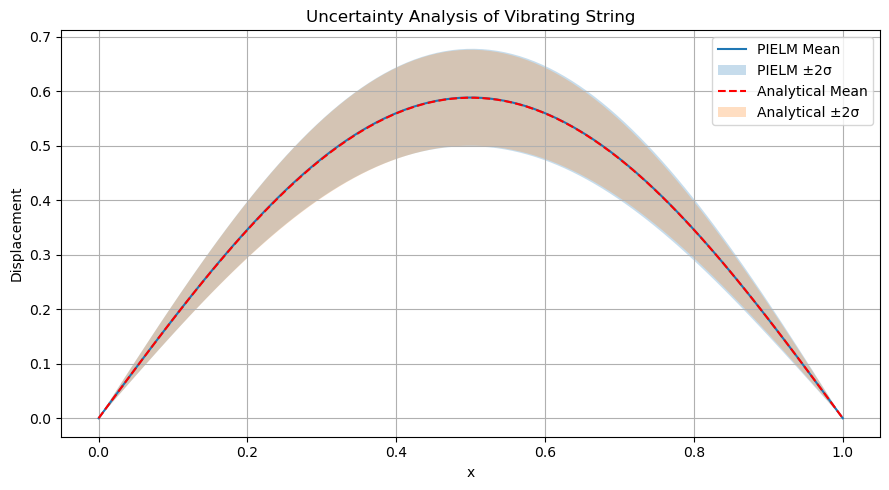

In [6]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
torch.set_default_dtype(torch.float32)

# =========================================================
# Latin Hypercube Sampling
# =========================================================
def latin_hypercube_sampling(n, d):
    H = torch.zeros(n, d)
    for j in range(d):
        perm = torch.randperm(n)
        H[:, j] = (perm + torch.rand(n)) / n
    return H

# =========================================================
# Physical parameters
# =========================================================
L = 1.0
T = 1.0
c_range = [0.9, 1.1]

def exact_solution(x, t, c):
    return torch.cos(c * np.pi * t) * torch.sin(np.pi * x)

# =========================================================
# ELM setup
# =========================================================
hidden_size = 150
W = torch.randn(3, hidden_size)
b = torch.randn(hidden_size)

def hidden_layer(X):
    return torch.exp(-(X @ W + b)**2)

# =========================================================
# PIELM solver (corrected)
# =========================================================
def solve_pielm():

    n_pde = 6000
    n_ic = 2000
    lambda_ic = 30.0

    # PDE points
    lhs = latin_hypercube_sampling(n_pde,3)
    x_pde = lhs[:,0:1]*L
    t_pde = lhs[:,1:2]*T
    c_pde = lhs[:,2:3]*(c_range[1]-c_range[0]) + c_range[0]

    X_pde = torch.cat([x_pde,t_pde,c_pde],dim=1).requires_grad_(True)

    H = hidden_layer(X_pde)
    x = X_pde[:,0:1]

    # Physics-aligned trial
    U = torch.sin(np.pi*x) * H

    A_cols = []
    for j in range(hidden_size):
        uj = U[:,j:j+1]

        grad = autograd.grad(uj.sum(), X_pde, create_graph=True)[0]
        uj_x = grad[:,0:1]
        uj_t = grad[:,1:2]

        uj_xx = autograd.grad(uj_x.sum(), X_pde, create_graph=True)[0][:,0:1]
        uj_tt = autograd.grad(uj_t.sum(), X_pde, create_graph=True)[0][:,1:2]

        c_vals = X_pde[:,2:3]
        A_cols.append(uj_tt - c_vals**2 * uj_xx)

    A = torch.hstack(A_cols)
    b_pde = torch.zeros(n_pde,1)

    # Initial conditions
    lhs_ic = latin_hypercube_sampling(n_ic,2)
    x_ic = lhs_ic[:,0:1]*L
    c_ic = lhs_ic[:,1:2]*(c_range[1]-c_range[0]) + c_range[0]
    t_ic = torch.zeros(n_ic,1)

    X_ic = torch.cat([x_ic,t_ic,c_ic],dim=1).requires_grad_(True)

    H_ic = hidden_layer(X_ic)
    x0 = X_ic[:,0:1]
    U_ic = torch.sin(np.pi*x0) * H_ic

    C1 = U_ic
    d1 = torch.sin(np.pi*x_ic)

    C2_cols = []
    for j in range(hidden_size):
        uj = U_ic[:,j:j+1]
        grad = autograd.grad(uj.sum(), X_ic, create_graph=True)[0]
        C2_cols.append(grad[:,1:2])

    C2 = torch.hstack(C2_cols)
    d2 = torch.zeros(n_ic,1)

    C = torch.vstack([C1,C2])
    d = torch.vstack([d1,d2])

    # KKT
    A_T, C_T = A.T, C.T
    KKT = torch.zeros(hidden_size + C.shape[0],
                      hidden_size + C.shape[0])

    KKT[:hidden_size,:hidden_size] = A_T @ A + 1e-6*torch.eye(hidden_size)
    KKT[:hidden_size,hidden_size:] = lambda_ic * C_T
    KKT[hidden_size:,:hidden_size] = lambda_ic * C

    rhs = torch.vstack([A_T@b_pde, lambda_ic*d])

    sol = torch.linalg.solve(KKT, rhs)
    return sol[:hidden_size]

# =========================================================
# Train model
# =========================================================
beta = solve_pielm()

def predict(X):
    return torch.sin(np.pi*X[:,0:1]) * (hidden_layer(X) @ beta)

# =========================================================
# MONTE CARLO (Mean & Variance vs x)
# =========================================================
n_mc = 5000
x_uq = torch.linspace(0, L, 100).reshape(-1, 1)
t_fixed = 0.3

c_mc = c_range[0] + torch.rand(n_mc,1)*(c_range[1]-c_range[0])

u_samples = []

for x_val in x_uq:
    x_rep = x_val.repeat(n_mc,1)
    t_rep = torch.ones_like(x_rep)*t_fixed
    X_mc = torch.cat([x_rep,t_rep,c_mc],dim=1)
    u_samples.append(predict(X_mc))

u_samples = torch.stack(u_samples)

u_mean = u_samples.mean(dim=1).squeeze()
u_std  = u_samples.std(dim=1).squeeze()

# Analytical mean & std
shape = torch.sin(np.pi*x_uq.squeeze())
cos_term = torch.cos(c_mc.squeeze()*np.pi*t_fixed)

u_mean_exact = shape * cos_term.mean()
u_std_exact  = shape.abs() * cos_term.std()

# =========================================================
# Plot Mean ±2σ
# =========================================================
plt.figure(figsize=(9,5))

plt.plot(x_uq.numpy(), u_mean.detach().numpy(), label="PIELM Mean")
plt.fill_between(x_uq.squeeze().numpy(),
                 (u_mean-2*u_std).detach().numpy(),
                 (u_mean+2*u_std).detach().numpy(),
                 alpha=0.25, label="PIELM ±2σ")

plt.plot(x_uq.numpy(), u_mean_exact.detach().numpy(),
         "r--", label="Analytical Mean")

plt.fill_between(x_uq.squeeze().numpy(),
                 (u_mean_exact-2*u_std_exact).detach().numpy(),
                 (u_mean_exact+2*u_std_exact).detach().numpy(),
                 alpha=0.25, label="Analytical ±2σ")

plt.xlabel("x")
plt.ylabel("Displacement")
plt.title("Uncertainty Analysis of Vibrating String")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Deterministic relative L2 error at c=1.00, t=0.3: 7.660185e-03


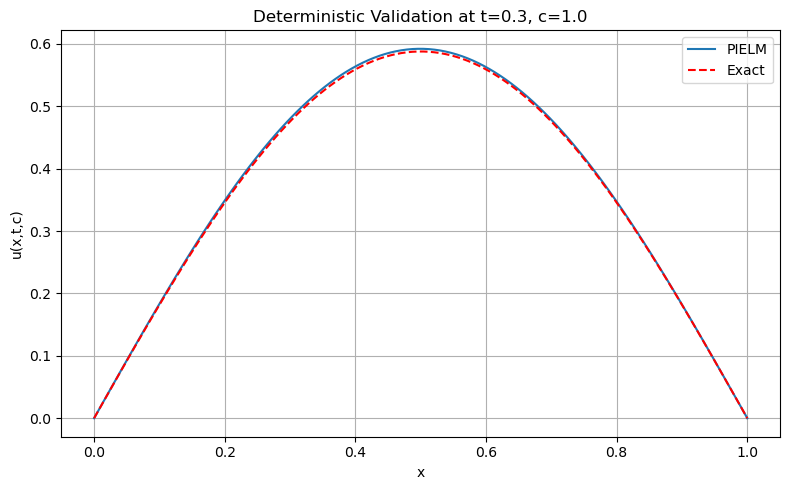

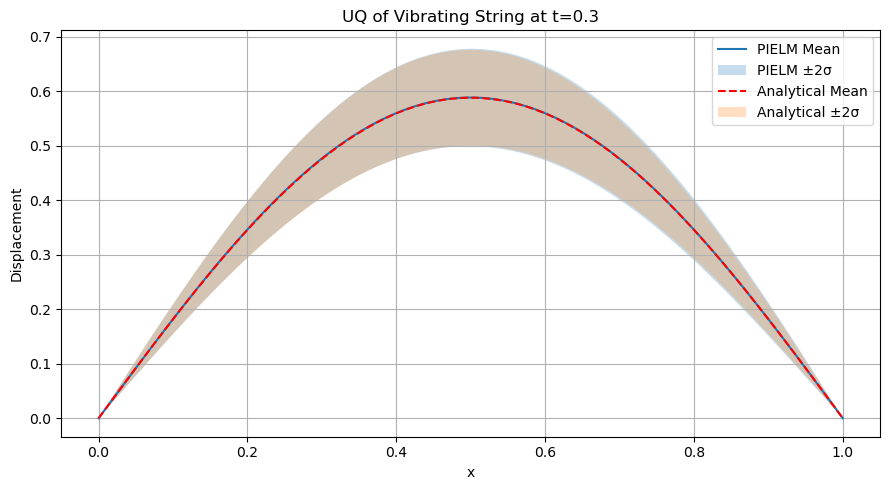

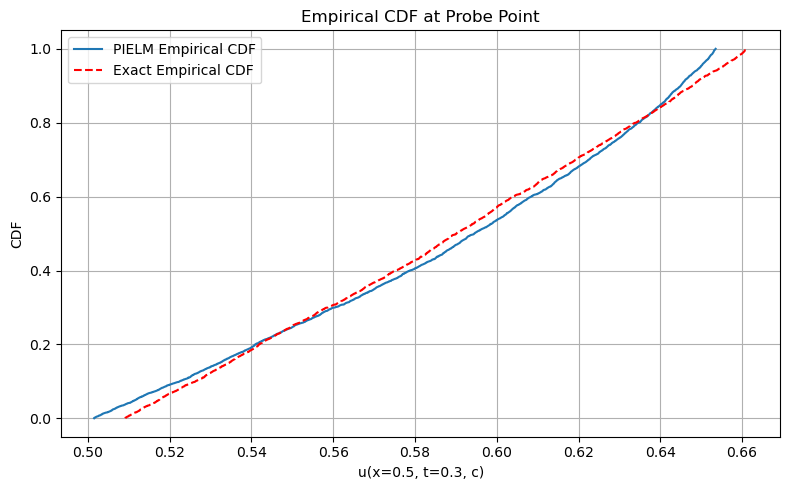

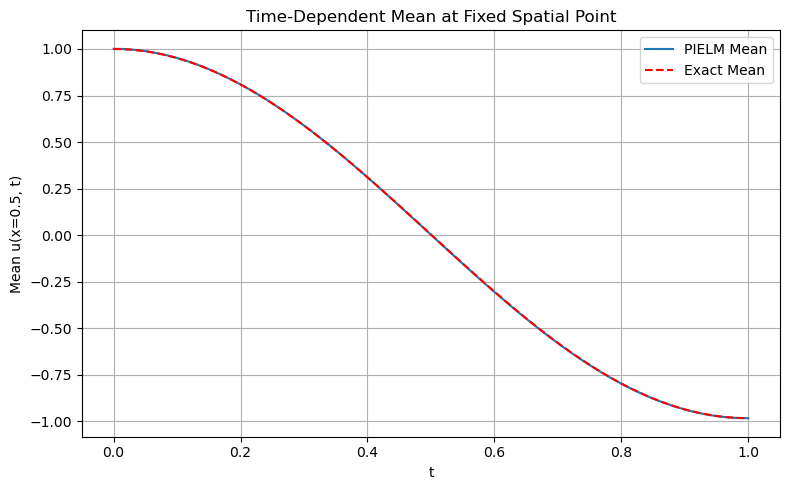

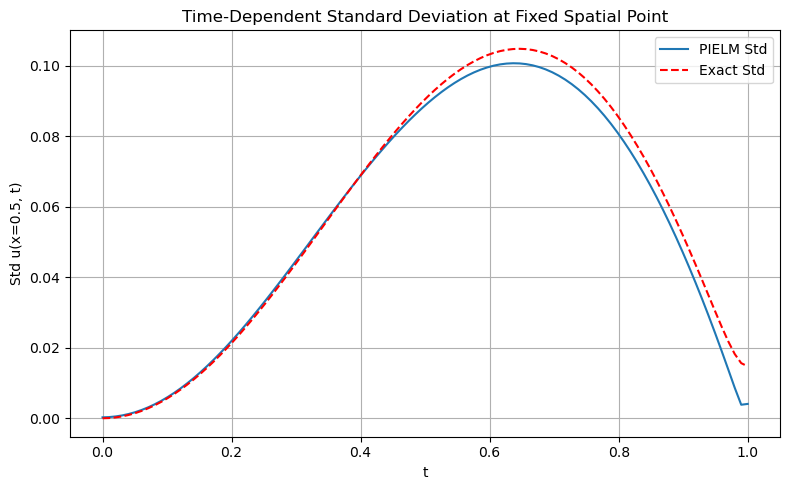

In [1]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
torch.set_default_dtype(torch.float32)

# =========================================================
# Problem setup
# =========================================================
L = 1.0
T = 1.0
c_range = [0.9, 1.1]

# =========================================================
# Exact solution
# u(x,t,c) = cos(c*pi*t) * sin(pi*x)
# =========================================================
def exact_solution(x, t, c):
    return torch.cos(c * np.pi * t) * torch.sin(np.pi * x)

# =========================================================
# Sampling strategies in augmented space (x, t, c)
# =========================================================
def latin_hypercube_sampling(n, d):
    H = torch.zeros(n, d)
    for j in range(d):
        perm = torch.randperm(n)
        H[:, j] = (perm + torch.rand(n)) / n
    return H

def monte_carlo_sampling(n, d):
    return torch.rand(n, d)

def generate_samples(n, d, method="lhs"):
    if method.lower() == "lhs":
        return latin_hypercube_sampling(n, d)
    elif method.lower() == "mc":
        return monte_carlo_sampling(n, d)
    else:
        raise ValueError("Unknown sampling method. Use 'lhs' or 'mc'.")

# =========================================================
# ELM / PIELM setup
# =========================================================
hidden_size = 150
input_dim = 3   # (x, t, c)
activation_name = "gaussian"   # options: gaussian, tanh, sigmoid

W = torch.randn(input_dim, hidden_size)
b = torch.randn(hidden_size)

def activation(z, kind="gaussian"):
    if kind == "gaussian":
        return torch.exp(-z**2)
    elif kind == "tanh":
        return torch.tanh(z)
    elif kind == "sigmoid":
        return torch.sigmoid(z)
    else:
        raise ValueError("Unsupported activation. Choose gaussian, tanh, or sigmoid.")

def hidden_layer(X):
    return activation(X @ W + b, activation_name)

# =========================================================
# Physics-aligned trial function
# Ensures homogeneous Dirichlet BCs at x=0 and x=L
# =========================================================
def trial_features(X):
    x = X[:, 0:1]
    return torch.sin(np.pi * x) * hidden_layer(X)

# =========================================================
# PIELM solver in augmented space
# PDE: u_tt - c^2 u_xx = 0
# ICs:
#   u(x,0,c) = sin(pi x)
#   u_t(x,0,c) = 0
# =========================================================
def solve_pielm(
    n_pde=6000,
    n_ic=2000,
    lambda_ic=30.0,
    sampling_method="lhs",
    reg=1e-6
):
    # -----------------------------------------------------
    # PDE collocation in augmented space (x, t, c)
    # -----------------------------------------------------
    lhs = generate_samples(n_pde, 3, method=sampling_method)

    x_pde = lhs[:, 0:1] * L
    t_pde = lhs[:, 1:2] * T
    c_pde = lhs[:, 2:3] * (c_range[1] - c_range[0]) + c_range[0]

    X_pde = torch.cat([x_pde, t_pde, c_pde], dim=1).requires_grad_(True)

    U = trial_features(X_pde)

    A_cols = []
    for j in range(hidden_size):
        uj = U[:, j:j+1]

        grad = autograd.grad(uj.sum(), X_pde, create_graph=True)[0]
        uj_x = grad[:, 0:1]
        uj_t = grad[:, 1:2]

        uj_xx = autograd.grad(uj_x.sum(), X_pde, create_graph=True)[0][:, 0:1]
        uj_tt = autograd.grad(uj_t.sum(), X_pde, create_graph=True)[0][:, 1:2]

        c_vals = X_pde[:, 2:3]
        A_cols.append(uj_tt - c_vals**2 * uj_xx)

    A = torch.hstack(A_cols)
    b_pde = torch.zeros(n_pde, 1)

    # -----------------------------------------------------
    # Initial condition points in augmented space (x, c)
    # -----------------------------------------------------
    lhs_ic = generate_samples(n_ic, 2, method=sampling_method)

    x_ic = lhs_ic[:, 0:1] * L
    c_ic = lhs_ic[:, 1:2] * (c_range[1] - c_range[0]) + c_range[0]
    t_ic = torch.zeros(n_ic, 1)

    X_ic = torch.cat([x_ic, t_ic, c_ic], dim=1).requires_grad_(True)

    U_ic = trial_features(X_ic)

    # u(x,0,c) = sin(pi x)
    C1 = U_ic
    d1 = torch.sin(np.pi * x_ic)

    # u_t(x,0,c) = 0
    C2_cols = []
    for j in range(hidden_size):
        uj = U_ic[:, j:j+1]
        grad = autograd.grad(uj.sum(), X_ic, create_graph=True)[0]
        C2_cols.append(grad[:, 1:2])

    C2 = torch.hstack(C2_cols)
    d2 = torch.zeros(n_ic, 1)

    C = torch.vstack([C1, C2])
    d = torch.vstack([d1, d2])

    # -----------------------------------------------------
    # Constrained/KKT system
    # -----------------------------------------------------
    A_T, C_T = A.T, C.T
    n_constraints = C.shape[0]

    KKT = torch.zeros(hidden_size + n_constraints, hidden_size + n_constraints)
    KKT[:hidden_size, :hidden_size] = A_T @ A + reg * torch.eye(hidden_size)
    KKT[:hidden_size, hidden_size:] = lambda_ic * C_T
    KKT[hidden_size:, :hidden_size] = lambda_ic * C

    rhs = torch.vstack([A_T @ b_pde, lambda_ic * d])

    sol = torch.linalg.solve(KKT, rhs)
    beta = sol[:hidden_size]

    return beta

# =========================================================
# Train model
# =========================================================
beta = solve_pielm(
    n_pde=6000,
    n_ic=2000,
    lambda_ic=30.0,
    sampling_method="lhs",
    reg=1e-6
)

def predict(X):
    return trial_features(X) @ beta

# =========================================================
# Deterministic validation
# Choose a fixed c and compare with exact solution
# =========================================================
c_det = 1.0
x_val = torch.linspace(0, L, 120).reshape(-1, 1)
t_val = torch.full_like(x_val, 0.3)
c_val = torch.full_like(x_val, c_det)

X_val = torch.cat([x_val, t_val, c_val], dim=1)
u_pred_det = predict(X_val).detach().squeeze()
u_exact_det = exact_solution(x_val, t_val, c_val).detach().squeeze()

rel_l2_error = torch.norm(u_pred_det - u_exact_det) / torch.norm(u_exact_det)
print(f"Deterministic relative L2 error at c={c_det:.2f}, t=0.3: {rel_l2_error.item():.6e}")

# =========================================================
# Monte Carlo UQ at fixed time: mean and std versus x
# =========================================================
n_mc = 5000
x_uq = torch.linspace(0, L, 100).reshape(-1, 1)
t_fixed = 0.3

c_mc = c_range[0] + torch.rand(n_mc, 1) * (c_range[1] - c_range[0])

u_samples = []
for xq in x_uq:
    x_rep = xq.repeat(n_mc, 1)
    t_rep = torch.full_like(x_rep, t_fixed)
    X_mc = torch.cat([x_rep, t_rep, c_mc], dim=1)
    u_samples.append(predict(X_mc).detach())

u_samples = torch.stack(u_samples)  # shape: [nx, n_mc, 1]

u_mean = u_samples.mean(dim=1).squeeze()
u_std = u_samples.std(dim=1).squeeze()

# Analytical mean and std
shape = torch.sin(np.pi * x_uq.squeeze())
cos_term = torch.cos(c_mc.squeeze() * np.pi * t_fixed)

u_mean_exact = shape * cos_term.mean()
u_std_exact = shape.abs() * cos_term.std()

# =========================================================
# Empirical CDF at a probe point (x*, t*)
# =========================================================
x_probe = 0.5
t_probe = 0.3

x_probe_rep = torch.full((n_mc, 1), x_probe)
t_probe_rep = torch.full((n_mc, 1), t_probe)
X_probe = torch.cat([x_probe_rep, t_probe_rep, c_mc], dim=1)

u_probe_pred = predict(X_probe).detach().squeeze()
u_probe_exact = exact_solution(x_probe_rep, t_probe_rep, c_mc).detach().squeeze()

u_probe_pred_sorted, _ = torch.sort(u_probe_pred)
u_probe_exact_sorted, _ = torch.sort(u_probe_exact)

cdf_vals = torch.linspace(1 / n_mc, 1.0, n_mc)

# =========================================================
# Time-dependent statistics at a fixed spatial point
# =========================================================
t_series = torch.linspace(0, T, 100).reshape(-1, 1)
x_fixed = 0.5

mean_t = []
std_t = []
mean_t_exact = []
std_t_exact = []

for tq in t_series:
    x_rep = torch.full((n_mc, 1), x_fixed)
    t_rep = torch.full((n_mc, 1), tq.item())
    X_tmp = torch.cat([x_rep, t_rep, c_mc], dim=1)

    up = predict(X_tmp).detach().squeeze()
    ue = exact_solution(x_rep, t_rep, c_mc).detach().squeeze()

    mean_t.append(up.mean())
    std_t.append(up.std())
    mean_t_exact.append(ue.mean())
    std_t_exact.append(ue.std())

mean_t = torch.stack(mean_t)
std_t = torch.stack(std_t)
mean_t_exact = torch.stack(mean_t_exact)
std_t_exact = torch.stack(std_t_exact)

# =========================================================
# Plot 1: Deterministic validation
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(x_val.numpy(), u_pred_det.numpy(), label="PIELM")
plt.plot(x_val.numpy(), u_exact_det.numpy(), "r--", label="Exact")
plt.xlabel("x")
plt.ylabel("u(x,t,c)")
plt.title(f"Deterministic Validation at t=0.3, c={c_det}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# Plot 2: Mean ± 2sigma versus x
# =========================================================
plt.figure(figsize=(9, 5))
plt.plot(x_uq.numpy(), u_mean.numpy(), label="PIELM Mean")
plt.fill_between(
    x_uq.squeeze().numpy(),
    (u_mean - 2 * u_std).numpy(),
    (u_mean + 2 * u_std).numpy(),
    alpha=0.25,
    label="PIELM ±2σ"
)

plt.plot(x_uq.numpy(), u_mean_exact.numpy(), "r--", label="Analytical Mean")
plt.fill_between(
    x_uq.squeeze().numpy(),
    (u_mean_exact - 2 * u_std_exact).numpy(),
    (u_mean_exact + 2 * u_std_exact).numpy(),
    alpha=0.25,
    label="Analytical ±2σ"
)

plt.xlabel("x")
plt.ylabel("Displacement")
plt.title(f"UQ of Vibrating String at t={t_fixed}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# Plot 3: Empirical CDF at probe point
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(u_probe_pred_sorted.numpy(), cdf_vals.numpy(), label="PIELM Empirical CDF")
plt.plot(u_probe_exact_sorted.numpy(), cdf_vals.numpy(), "r--", label="Exact Empirical CDF")
plt.xlabel(f"u(x={x_probe}, t={t_probe}, c)")
plt.ylabel("CDF")
plt.title("Empirical CDF at Probe Point")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# Plot 4: Time-dependent mean at fixed x
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(t_series.numpy(), mean_t.numpy(), label="PIELM Mean")
plt.plot(t_series.numpy(), mean_t_exact.numpy(), "r--", label="Exact Mean")
plt.xlabel("t")
plt.ylabel(f"Mean u(x={x_fixed}, t)")
plt.title("Time-Dependent Mean at Fixed Spatial Point")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# Plot 5: Time-dependent std at fixed x
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(t_series.numpy(), std_t.numpy(), label="PIELM Std")
plt.plot(t_series.numpy(), std_t_exact.numpy(), "r--", label="Exact Std")
plt.xlabel("t")
plt.ylabel(f"Std u(x={x_fixed}, t)")
plt.title("Time-Dependent Standard Deviation at Fixed Spatial Point")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Deterministic relative L2 error at c=1.00, t=0.3: 7.660185e-03

Sensitivity analysis for vibrating string
Probe point: x = 0.5, t = 0.3, c = 1.0
u(x,t,c) = 5.921040e-01
∂u/∂c (PIELM) = -7.906685e-01
Normalized sensitivity wrt c (PIELM) = -1.335354
∂u/∂c (Exact) = -7.624806e-01
Normalized sensitivity wrt c (Exact) = -1.297209


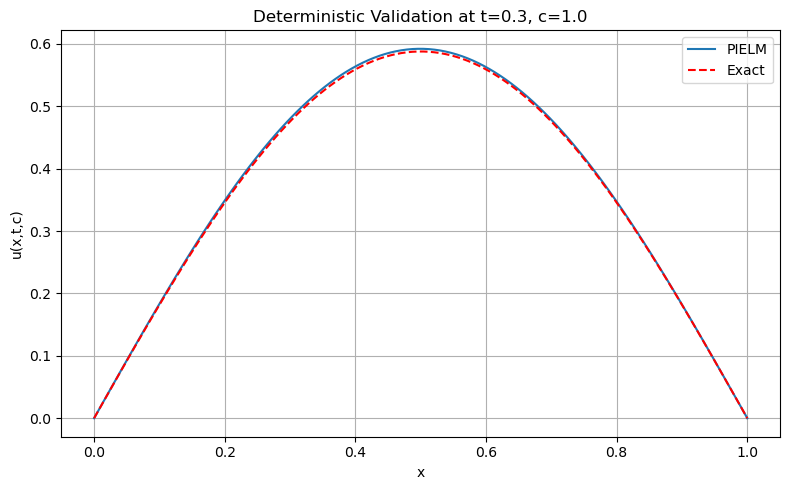

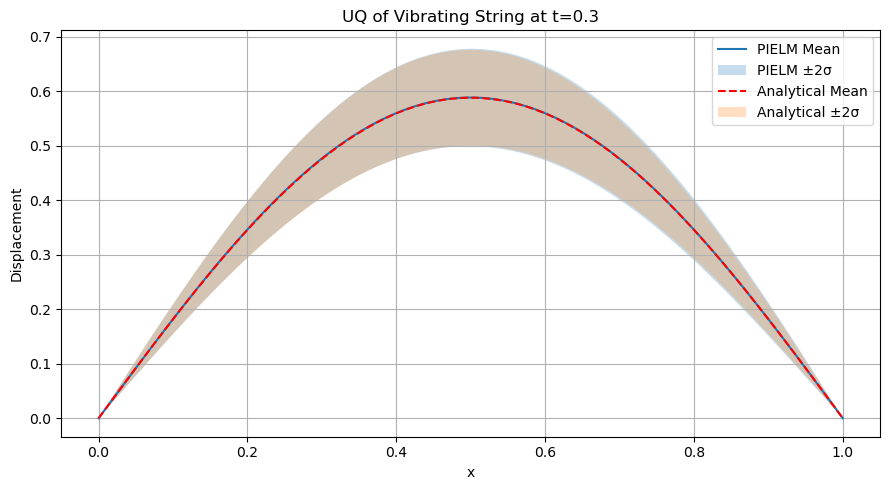

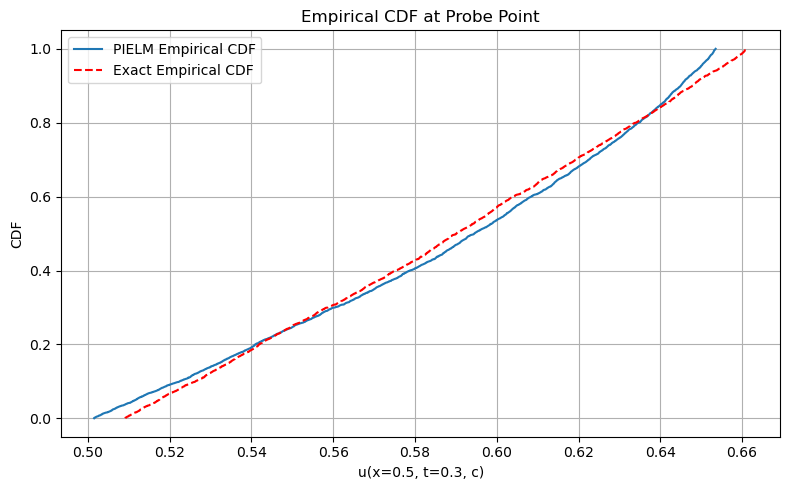

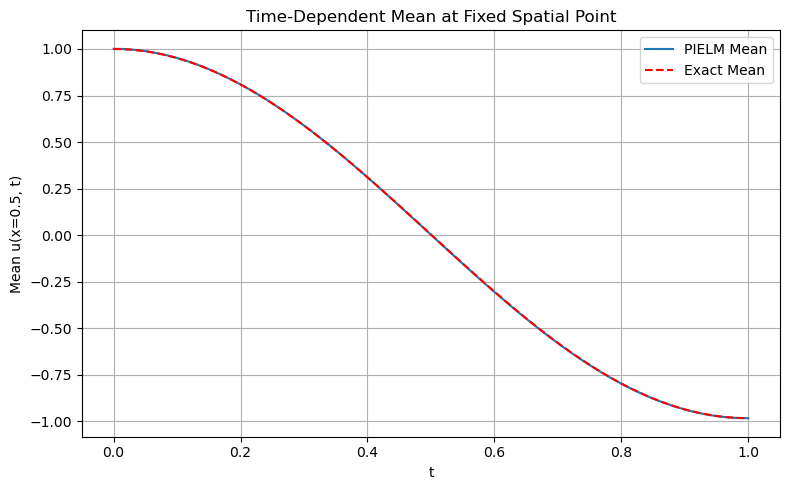

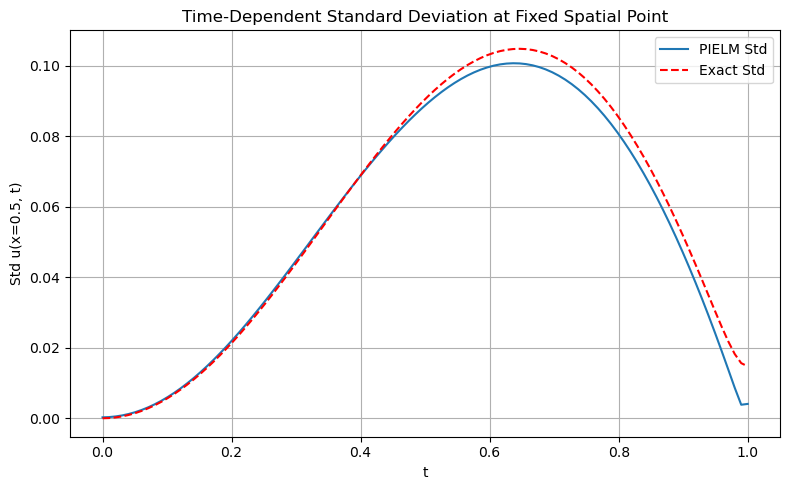

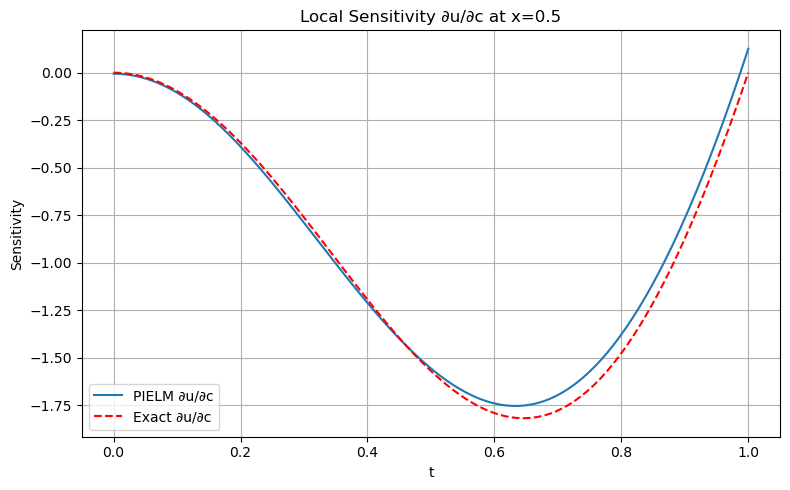

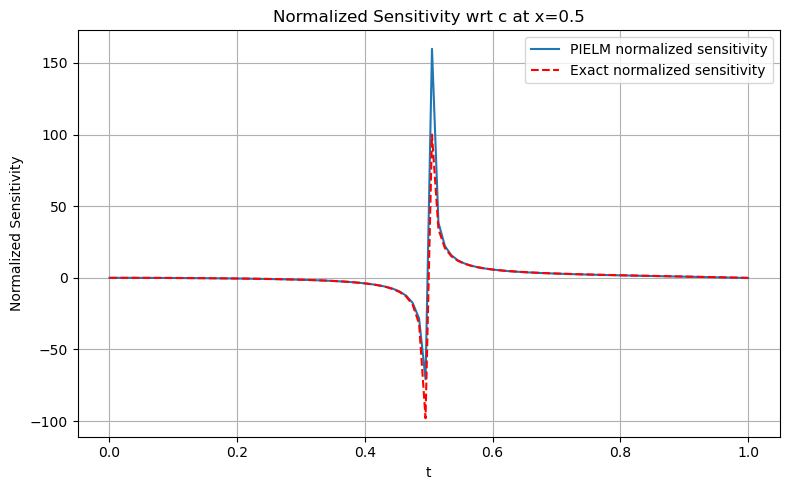

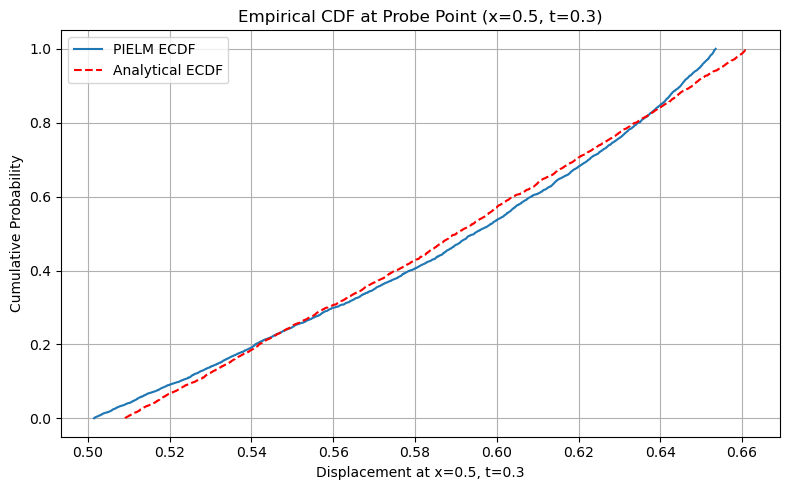


SELECTED CDF VALUES at x = 0.5, t = 0.3
Displacement Threshold u  PIELM CDF       Analytical CDF  Difference  
----------------------------------------------------------------------
u <=  0.50150                0.0002            0.0000            0.0002
u <=  0.54145                0.2028            0.1950            0.0078
u <=  0.58140                0.4134            0.4368            0.0234
u <=  0.62135                0.6908            0.7130            0.0222
u <=  0.66129                1.0000            1.0000            0.0000


In [2]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
torch.set_default_dtype(torch.float32)

# =========================================================
# Problem setup
# =========================================================
L = 1.0
T = 1.0
c_range = [0.9, 1.1]

# =========================================================
# Exact solution
# u(x,t,c) = cos(c*pi*t) * sin(pi*x)
# =========================================================
def exact_solution(x, t, c):
    return torch.cos(c * np.pi * t) * torch.sin(np.pi * x)

# =========================================================
# Sampling strategies in augmented space (x, t, c)
# =========================================================
def latin_hypercube_sampling(n, d):
    H = torch.zeros(n, d)
    for j in range(d):
        perm = torch.randperm(n)
        H[:, j] = (perm + torch.rand(n)) / n
    return H

def monte_carlo_sampling(n, d):
    return torch.rand(n, d)

def generate_samples(n, d, method="lhs"):
    if method.lower() == "lhs":
        return latin_hypercube_sampling(n, d)
    elif method.lower() == "mc":
        return monte_carlo_sampling(n, d)
    else:
        raise ValueError("Unknown sampling method. Use 'lhs' or 'mc'.")

# =========================================================
# ELM / PIELM setup
# =========================================================
hidden_size = 150
input_dim = 3   # (x, t, c)
activation_name = "gaussian"   # options: gaussian, tanh, sigmoid

W = torch.randn(input_dim, hidden_size)
b = torch.randn(hidden_size)

def activation(z, kind="gaussian"):
    if kind == "gaussian":
        return torch.exp(-z**2)
    elif kind == "tanh":
        return torch.tanh(z)
    elif kind == "sigmoid":
        return torch.sigmoid(z)
    else:
        raise ValueError("Unsupported activation. Choose gaussian, tanh, or sigmoid.")

def hidden_layer(X):
    return activation(X @ W + b, activation_name)

# =========================================================
# Physics-aligned trial function
# Ensures homogeneous Dirichlet BCs at x=0 and x=L
# =========================================================
def trial_features(X):
    x = X[:, 0:1]
    return torch.sin(np.pi * x) * hidden_layer(X)

# =========================================================
# PIELM solver in augmented space
# PDE: u_tt - c^2 u_xx = 0
# ICs:
#   u(x,0,c) = sin(pi x)
#   u_t(x,0,c) = 0
# =========================================================
def solve_pielm(
    n_pde=6000,
    n_ic=2000,
    lambda_ic=30.0,
    sampling_method="lhs",
    reg=1e-6
):
    # -----------------------------------------------------
    # PDE collocation in augmented space (x, t, c)
    # -----------------------------------------------------
    lhs = generate_samples(n_pde, 3, method=sampling_method)

    x_pde = lhs[:, 0:1] * L
    t_pde = lhs[:, 1:2] * T
    c_pde = lhs[:, 2:3] * (c_range[1] - c_range[0]) + c_range[0]

    X_pde = torch.cat([x_pde, t_pde, c_pde], dim=1).requires_grad_(True)

    U = trial_features(X_pde)

    A_cols = []
    for j in range(hidden_size):
        uj = U[:, j:j+1]

        grad = autograd.grad(uj.sum(), X_pde, create_graph=True)[0]
        uj_x = grad[:, 0:1]
        uj_t = grad[:, 1:2]

        uj_xx = autograd.grad(uj_x.sum(), X_pde, create_graph=True)[0][:, 0:1]
        uj_tt = autograd.grad(uj_t.sum(), X_pde, create_graph=True)[0][:, 1:2]

        c_vals = X_pde[:, 2:3]
        A_cols.append(uj_tt - c_vals**2 * uj_xx)

    A = torch.hstack(A_cols)
    b_pde = torch.zeros(n_pde, 1)

    # -----------------------------------------------------
    # Initial condition points in augmented space (x, c)
    # -----------------------------------------------------
    lhs_ic = generate_samples(n_ic, 2, method=sampling_method)

    x_ic = lhs_ic[:, 0:1] * L
    c_ic = lhs_ic[:, 1:2] * (c_range[1] - c_range[0]) + c_range[0]
    t_ic = torch.zeros(n_ic, 1)

    X_ic = torch.cat([x_ic, t_ic, c_ic], dim=1).requires_grad_(True)

    U_ic = trial_features(X_ic)

    # u(x,0,c) = sin(pi x)
    C1 = U_ic
    d1 = torch.sin(np.pi * x_ic)

    # u_t(x,0,c) = 0
    C2_cols = []
    for j in range(hidden_size):
        uj = U_ic[:, j:j+1]
        grad = autograd.grad(uj.sum(), X_ic, create_graph=True)[0]
        C2_cols.append(grad[:, 1:2])

    C2 = torch.hstack(C2_cols)
    d2 = torch.zeros(n_ic, 1)

    C = torch.vstack([C1, C2])
    d = torch.vstack([d1, d2])

    # -----------------------------------------------------
    # Constrained/KKT system
    # -----------------------------------------------------
    A_T, C_T = A.T, C.T
    n_constraints = C.shape[0]

    KKT = torch.zeros(hidden_size + n_constraints, hidden_size + n_constraints)
    KKT[:hidden_size, :hidden_size] = A_T @ A + reg * torch.eye(hidden_size)
    KKT[:hidden_size, hidden_size:] = lambda_ic * C_T
    KKT[hidden_size:, :hidden_size] = lambda_ic * C

    rhs = torch.vstack([A_T @ b_pde, lambda_ic * d])

    sol = torch.linalg.solve(KKT, rhs)
    beta = sol[:hidden_size]

    return beta

# =========================================================
# Train model
# =========================================================
beta = solve_pielm(
    n_pde=6000,
    n_ic=2000,
    lambda_ic=30.0,
    sampling_method="lhs",
    reg=1e-6
)

def predict(X):
    return trial_features(X) @ beta

# =========================================================
# Deterministic validation
# Choose a fixed c and compare with exact solution
# =========================================================
c_det = 1.0
x_val = torch.linspace(0, L, 120).reshape(-1, 1)
t_val = torch.full_like(x_val, 0.3)
c_val = torch.full_like(x_val, c_det)

X_val = torch.cat([x_val, t_val, c_val], dim=1)
u_pred_det = predict(X_val).detach().squeeze()
u_exact_det = exact_solution(x_val, t_val, c_val).detach().squeeze()

rel_l2_error = torch.norm(u_pred_det - u_exact_det) / torch.norm(u_exact_det)
print(f"Deterministic relative L2 error at c={c_det:.2f}, t=0.3: {rel_l2_error.item():.6e}")

# =========================================================
# Monte Carlo UQ at fixed time: mean and std versus x
# =========================================================
n_mc = 5000
x_uq = torch.linspace(0, L, 100).reshape(-1, 1)
t_fixed = 0.3

c_mc = c_range[0] + torch.rand(n_mc, 1) * (c_range[1] - c_range[0])

u_samples = []
for xq in x_uq:
    x_rep = xq.repeat(n_mc, 1)
    t_rep = torch.full_like(x_rep, t_fixed)
    X_mc = torch.cat([x_rep, t_rep, c_mc], dim=1)
    u_samples.append(predict(X_mc).detach())

u_samples = torch.stack(u_samples)  # shape: [nx, n_mc, 1]

u_mean = u_samples.mean(dim=1).squeeze()
u_std = u_samples.std(dim=1).squeeze()

# Analytical mean and std
shape = torch.sin(np.pi * x_uq.squeeze())
cos_term = torch.cos(c_mc.squeeze() * np.pi * t_fixed)

u_mean_exact = shape * cos_term.mean()
u_std_exact = shape.abs() * cos_term.std()

# =========================================================
# Empirical CDF at a probe point (x*, t*)
# =========================================================
x_probe = 0.5
t_probe = 0.3

x_probe_rep = torch.full((n_mc, 1), x_probe)
t_probe_rep = torch.full((n_mc, 1), t_probe)
X_probe = torch.cat([x_probe_rep, t_probe_rep, c_mc], dim=1)

u_probe_pred = predict(X_probe).detach().squeeze()
u_probe_exact = exact_solution(x_probe_rep, t_probe_rep, c_mc).detach().squeeze()

u_probe_pred_sorted, _ = torch.sort(u_probe_pred)
u_probe_exact_sorted, _ = torch.sort(u_probe_exact)

cdf_vals = torch.linspace(1 / n_mc, 1.0, n_mc)

# =========================================================
# Time-dependent statistics at a fixed spatial point
# =========================================================
t_series = torch.linspace(0, T, 100).reshape(-1, 1)
x_fixed = 0.5

mean_t = []
std_t = []
mean_t_exact = []
std_t_exact = []

for tq in t_series:
    x_rep = torch.full((n_mc, 1), x_fixed)
    t_rep = torch.full((n_mc, 1), tq.item())
    X_tmp = torch.cat([x_rep, t_rep, c_mc], dim=1)

    up = predict(X_tmp).detach().squeeze()
    ue = exact_solution(x_rep, t_rep, c_mc).detach().squeeze()

    mean_t.append(up.mean())
    std_t.append(up.std())
    mean_t_exact.append(ue.mean())
    std_t_exact.append(ue.std())

mean_t = torch.stack(mean_t)
std_t = torch.stack(std_t)
mean_t_exact = torch.stack(mean_t_exact)
std_t_exact = torch.stack(std_t_exact)

# =========================================================
# SENSITIVITY ANALYSIS WITH RESPECT TO c
# =========================================================
x_sens = 0.5
t_sens = 0.3
c_sens = 1.0

x_ref = torch.tensor([[x_sens]], requires_grad=True)
t_ref = torch.tensor([[t_sens]], requires_grad=True)
c_ref = torch.tensor([[c_sens]], requires_grad=True)

X_ref = torch.cat([x_ref, t_ref, c_ref], dim=1)

u_ref = predict(X_ref)

# Local sensitivity du/dc
du_dc = torch.autograd.grad(u_ref, c_ref, retain_graph=True)[0]

# Normalized sensitivity
S_c = (c_ref / u_ref) * du_dc

# Exact sensitivity for comparison
du_dc_exact = -np.pi * t_sens * np.sin(c_sens * np.pi * t_sens) * np.sin(np.pi * x_sens)
u_exact_ref = np.cos(c_sens * np.pi * t_sens) * np.sin(np.pi * x_sens)
S_c_exact = (c_sens / u_exact_ref) * du_dc_exact

print("\nSensitivity analysis for vibrating string")
print(f"Probe point: x = {x_sens}, t = {t_sens}, c = {c_sens}")
print(f"u(x,t,c) = {u_ref.item():.6e}")
print(f"∂u/∂c (PIELM) = {du_dc.item():.6e}")
print(f"Normalized sensitivity wrt c (PIELM) = {S_c.item():.6f}")
print(f"∂u/∂c (Exact) = {du_dc_exact:.6e}")
print(f"Normalized sensitivity wrt c (Exact) = {S_c_exact:.6f}")

# =========================================================
# Time-dependent sensitivity wrt c at fixed x
# =========================================================
x_fixed_sens = 0.5
c_fixed_sens = 1.0
t_sens_series = torch.linspace(0, T, 100).reshape(-1, 1)

du_dc_series = []
S_c_series = []
du_dc_exact_series = []
S_c_exact_series = []

for t_val in t_sens_series:
    x_tmp = torch.tensor([[x_fixed_sens]], requires_grad=True)
    t_tmp = torch.tensor([[t_val.item()]], requires_grad=True)
    c_tmp = torch.tensor([[c_fixed_sens]], requires_grad=True)

    X_tmp = torch.cat([x_tmp, t_tmp, c_tmp], dim=1)
    u_tmp = predict(X_tmp)

    du_dc_tmp = torch.autograd.grad(u_tmp, c_tmp, retain_graph=True)[0]
    S_c_tmp = (c_tmp / u_tmp) * du_dc_tmp

    du_dc_series.append(du_dc_tmp.detach().squeeze())
    S_c_series.append(S_c_tmp.detach().squeeze())

    # Exact values
    t_np = t_val.item()
    u_ex = np.cos(c_fixed_sens * np.pi * t_np) * np.sin(np.pi * x_fixed_sens)
    du_ex = -np.pi * t_np * np.sin(c_fixed_sens * np.pi * t_np) * np.sin(np.pi * x_fixed_sens)

    du_dc_exact_series.append(torch.tensor(du_ex, dtype=torch.float32))
    S_c_exact_series.append(torch.tensor((c_fixed_sens / u_ex) * du_ex, dtype=torch.float32) if abs(u_ex) > 1e-12 else torch.tensor(float("nan")))

du_dc_series = torch.stack(du_dc_series)
S_c_series = torch.stack(S_c_series)
du_dc_exact_series = torch.stack(du_dc_exact_series)
S_c_exact_series = torch.stack(S_c_exact_series)

# =========================================================
# Plot 1: Deterministic validation
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(x_val.numpy(), u_pred_det.numpy(), label="PIELM")
plt.plot(x_val.numpy(), u_exact_det.numpy(), "r--", label="Exact")
plt.xlabel("x")
plt.ylabel("u(x,t,c)")
plt.title(f"Deterministic Validation at t=0.3, c={c_det}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# Plot 2: Mean ± 2sigma versus x
# =========================================================
plt.figure(figsize=(9, 5))
plt.plot(x_uq.numpy(), u_mean.numpy(), label="PIELM Mean")
plt.fill_between(
    x_uq.squeeze().numpy(),
    (u_mean - 2 * u_std).numpy(),
    (u_mean + 2 * u_std).numpy(),
    alpha=0.25,
    label="PIELM ±2σ"
)

plt.plot(x_uq.numpy(), u_mean_exact.numpy(), "r--", label="Analytical Mean")
plt.fill_between(
    x_uq.squeeze().numpy(),
    (u_mean_exact - 2 * u_std_exact).numpy(),
    (u_mean_exact + 2 * u_std_exact).numpy(),
    alpha=0.25,
    label="Analytical ±2σ"
)

plt.xlabel("x")
plt.ylabel("Displacement")
plt.title(f"UQ of Vibrating String at t={t_fixed}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# Plot 3: Empirical CDF at probe point
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(u_probe_pred_sorted.numpy(), cdf_vals.numpy(), label="PIELM Empirical CDF")
plt.plot(u_probe_exact_sorted.numpy(), cdf_vals.numpy(), "r--", label="Exact Empirical CDF")
plt.xlabel(f"u(x={x_probe}, t={t_probe}, c)")
plt.ylabel("CDF")
plt.title("Empirical CDF at Probe Point")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# Plot 4: Time-dependent mean at fixed x
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(t_series.numpy(), mean_t.numpy(), label="PIELM Mean")
plt.plot(t_series.numpy(), mean_t_exact.numpy(), "r--", label="Exact Mean")
plt.xlabel("t")
plt.ylabel(f"Mean u(x={x_fixed}, t)")
plt.title("Time-Dependent Mean at Fixed Spatial Point")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# Plot 5: Time-dependent std at fixed x
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(t_series.numpy(), std_t.numpy(), label="PIELM Std")
plt.plot(t_series.numpy(), std_t_exact.numpy(), "r--", label="Exact Std")
plt.xlabel("t")
plt.ylabel(f"Std u(x={x_fixed}, t)")
plt.title("Time-Dependent Standard Deviation at Fixed Spatial Point")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# Plot 6: Local sensitivity du/dc over time at fixed x
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(t_sens_series.numpy(), du_dc_series.numpy(), label="PIELM ∂u/∂c")
plt.plot(t_sens_series.numpy(), du_dc_exact_series.numpy(), "r--", label="Exact ∂u/∂c")
plt.xlabel("t")
plt.ylabel("Sensitivity")
plt.title(f"Local Sensitivity ∂u/∂c at x={x_fixed_sens}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# Plot 7: Normalized sensitivity wrt c over time at fixed x
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(t_sens_series.numpy(), S_c_series.numpy(), label="PIELM normalized sensitivity")
plt.plot(t_sens_series.numpy(), S_c_exact_series.numpy(), "r--", label="Exact normalized sensitivity")
plt.xlabel("t")
plt.ylabel("Normalized Sensitivity")
plt.title(f"Normalized Sensitivity wrt c at x={x_fixed_sens}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()# =============================================================================
# EMPIRICAL CDF (ECDF) OF DISPLACEMENT
# =============================================================================
# Choose probe point
x_probe = 0.5
t_probe = 0.3

x_probe_rep = torch.full((n_mc, 1), x_probe)
t_probe_rep = torch.full((n_mc, 1), t_probe)
xtc_probe = torch.cat([x_probe_rep, t_probe_rep, c_mc], dim=1)

u_pielm = predict(xtc_probe).detach().squeeze()
u_exact = analytical_solution(x_probe_rep, t_probe_rep, c_mc).detach().squeeze()

# ECDF plot
x_pielm_sorted, F_pielm = ecdf_torch(u_pielm)
x_exact_sorted, F_exact = ecdf_torch(u_exact)

plt.figure(figsize=(8, 5))
plt.plot(x_pielm_sorted.numpy(), F_pielm.numpy(), label="PIELM ECDF")
plt.plot(x_exact_sorted.numpy(), F_exact.numpy(), "r--", label="Analytical ECDF")
plt.xlabel(f"Displacement at x={x_probe}, t={t_probe}")
plt.ylabel("Cumulative Probability")
plt.title(f"Empirical CDF at Probe Point (x={x_probe}, t={t_probe})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =============================================================================
# ECDF TABLE: SELECTED CDF VALUES
# =============================================================================
# Define specific displacement thresholds based on the data range
u_min = min(u_pielm.min(), u_exact.min()).item()
u_max = max(u_pielm.max(), u_exact.max()).item()
thresholds = torch.linspace(u_min, u_max, 5)

print(f"\n{'='*70}")
print(f"SELECTED CDF VALUES at x = {x_probe}, t = {t_probe}")
print(f"{'='*70}")
print(f"{'Displacement Threshold u':<25} {'PIELM CDF':<15} {'Analytical CDF':<15} {'Difference':<12}")
print(f"{'-'*70}")

for t in thresholds:
    cdf_pielm = (u_pielm <= t).float().mean().item()
    cdf_exact = (u_exact <= t).float().mean().item()
    diff = abs(cdf_pielm - cdf_exact)
    print(f"u <= {t.item(): .5f}{'':<15} {cdf_pielm:.4f}{'':<11} {cdf_exact:.4f}{'':<11} {diff:.4f}")

print(f"{'='*70}")